# Convolutional Neural Network for Skin Lesion Classification

### Import packages

In [ ]:
from pathlib import Path
import requests, zipfile
import pandas as pd
from PIL import Image
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader, Sampler
import torchvision
from torchvision import datasets, models, transforms
from torchvision.transforms import v2
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
import time
import os
import copy
import torch.backends.cudnn as cudnn
from tempfile import TemporaryDirectory
import random
from collections import defaultdict
import math
from sklearn.metrics import precision_score, recall_score, f1_score, balanced_accuracy_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import classification_report

### Download skin lesion dataset from ISIC Archive (link: https://challenge.isic-archive.com/data/#2018)

In [ ]:
# Setup paths
DATA_PATH = Path("data/HAM10000")
DATA_PATH.mkdir(parents=True, exist_ok=True)

# URLs
TRAIN_IMAGES_ZIP_URL = "https://isic-challenge-data.s3.amazonaws.com/2018/ISIC2018_Task3_Training_Input.zip"
TRAIN_LABELS_ZIP_URL = "https://isic-archive.s3.amazonaws.com/challenges/2018/ISIC2018_Task3_Training_GroundTruth.zip"

VAL_IMAGES_ZIP_URL = "https://isic-archive.s3.amazonaws.com/challenges/2018/ISIC2018_Task3_Validation_Input.zip"
VAL_LABELS_ZIP_URL = "https://isic-archive.s3.amazonaws.com/challenges/2018/ISIC2018_Task3_Validation_GroundTruth.zip"

# File paths
train_images_zip_path = DATA_PATH / "ISIC2018_Task3_Training_Input.zip"
train_labels_zip_path = DATA_PATH / "ISIC2018_Task3_Training_GroundTruth.zip"

val_images_zip_path = DATA_PATH / "ISIC2018_Task3_Validation_Input.zip"
val_labels_zip_path = DATA_PATH / "ISIC2018_Task3_Validation_GroundTruth.zip"

# Extracted directories and files
train_images_dir = DATA_PATH / "ISIC2018_Task3_Training_Input"
val_images_dir   = DATA_PATH / "ISIC2018_Task3_Validation_Input"

train_labels_csv_path = DATA_PATH / "ISIC2018_Task3_Training_GroundTruth.csv"
val_labels_csv_path   = DATA_PATH / "ISIC2018_Task3_Validation_GroundTruth.csv"


# Helper: Download + Extract
def download_and_extract(url, zip_path, extract_to):
    if not zip_path.exists():
        print(f"Downloading {zip_path.name}...")
        r = requests.get(url)
        with open(zip_path, "wb") as f:
            f.write(r.content)
    if not extract_to.exists():
        print(f"Extracting {zip_path.name}...")
        with zipfile.ZipFile(zip_path, "r") as zip_ref:
            zip_ref.extractall(DATA_PATH)


# TRAINING DATA
download_and_extract(TRAIN_IMAGES_ZIP_URL, train_images_zip_path, train_images_dir)
download_and_extract(TRAIN_LABELS_ZIP_URL, train_labels_zip_path, train_labels_csv_path)

# Find train labels CSV file
train_label_files = list(DATA_PATH.rglob("ISIC2018_Task3_Training_GroundTruth.csv"))
if len(train_label_files) == 0:
    raise FileNotFoundError("Could not find training labels CSV after extraction!")
train_labels_csv_path = train_label_files[0]

print("Found training labels CSV at:", train_labels_csv_path)

# Load train labels
train_df = pd.read_csv(train_labels_csv_path)
print("Train Labels CSV shape:", train_df.shape)
print(train_df.head())

# Convert one-hot to class index
train_df["label"] = train_df.iloc[:, 1:].idxmax(axis=1)
train_class_names = list(train_df.columns[1:-1])
train_class_to_idx = {cls: i for i, cls in enumerate(train_class_names)}
train_df["label_idx"] = train_df["label"].map(train_class_to_idx)

print("Train Classes:", train_class_to_idx)
print(train_df.head())


# VALIDATION DATA
download_and_extract(VAL_IMAGES_ZIP_URL, val_images_zip_path, val_images_dir)
download_and_extract(VAL_LABELS_ZIP_URL, val_labels_zip_path, val_labels_csv_path)

# Find val labels CSV file
val_label_files = list(DATA_PATH.rglob("ISIC2018_Task3_Validation_GroundTruth.csv"))
if len(val_label_files) == 0:
    raise FileNotFoundError("Could not find validation labels CSV after extraction!")
val_labels_csv_path = val_label_files[0]

print("Found validation labels CSV at:", val_labels_csv_path)

# Load val labels
val_df = pd.read_csv(val_labels_csv_path)
print("Validation Labels CSV shape:", val_df.shape)
print(val_df.head())

# Convert one-hot to class index
val_df["label"] = val_df.iloc[:, 1:].idxmax(axis=1)
val_df["label_idx"] = val_df["label"].map(train_class_to_idx)

print("Validation Classes:", train_class_to_idx)
print(val_df.head())

# Summary
class_names = train_class_names
print("\nData ready:")
print(f"Training images: {len(list(train_images_dir.glob('*.jpg')))}")
print(f"Validation images: {len(list(val_images_dir.glob('*.jpg')))}")
print(f"Classes: {train_class_to_idx}")
print(f"Class names: {class_names}")

Extracting ISIC2018_Task3_Training_Input.zip...
Extracting ISIC2018_Task3_Training_GroundTruth.zip...
Found training labels CSV at: data/HAM10000/ISIC2018_Task3_Training_GroundTruth/ISIC2018_Task3_Training_GroundTruth.csv
Train Labels CSV shape: (10015, 8)
          image  MEL   NV  BCC  AKIEC  BKL   DF  VASC
0  ISIC_0024306  0.0  1.0  0.0    0.0  0.0  0.0   0.0
1  ISIC_0024307  0.0  1.0  0.0    0.0  0.0  0.0   0.0
2  ISIC_0024308  0.0  1.0  0.0    0.0  0.0  0.0   0.0
3  ISIC_0024309  0.0  1.0  0.0    0.0  0.0  0.0   0.0
4  ISIC_0024310  1.0  0.0  0.0    0.0  0.0  0.0   0.0
Train Classes: {'MEL': 0, 'NV': 1, 'BCC': 2, 'AKIEC': 3, 'BKL': 4, 'DF': 5, 'VASC': 6}
          image  MEL   NV  BCC  AKIEC  BKL   DF  VASC label  label_idx
0  ISIC_0024306  0.0  1.0  0.0    0.0  0.0  0.0   0.0    NV          1
1  ISIC_0024307  0.0  1.0  0.0    0.0  0.0  0.0   0.0    NV          1
2  ISIC_0024308  0.0  1.0  0.0    0.0  0.0  0.0   0.0    NV          1
3  ISIC_0024309  0.0  1.0  0.0    0.0  0.0  0.0 

In [ ]:
# Download test data

# URLs
TEST_IMAGES_ZIP_URL = "https://isic-archive.s3.amazonaws.com/challenges/2018/ISIC2018_Task3_Test_Input.zip"
TEST_LABELS_ZIP_URL = "https://isic-archive.s3.amazonaws.com/challenges/2018/ISIC2018_Task3_Test_GroundTruth.zip"

# File paths
test_images_zip_path = DATA_PATH / "ISIC2018_Task3_Test_Input.zip"
test_labels_zip_path = DATA_PATH / "ISIC2018_Task3_Test_GroundTruth.zip"

# Extracted directories and files
test_images_dir = DATA_PATH / "ISIC2018_Task3_Test_Input"
test_labels_csv_path = DATA_PATH / "ISIC2018_Task3_Test_GroundTruth.csv"

# TEST DATA
download_and_extract(TEST_IMAGES_ZIP_URL, test_images_zip_path, test_images_dir)
download_and_extract(TEST_LABELS_ZIP_URL, test_labels_zip_path, test_labels_csv_path)

# Find test labels CSV file
test_label_files = list(DATA_PATH.rglob("ISIC2018_Task3_Test_GroundTruth.csv"))
if len(test_label_files) == 0:
    raise FileNotFoundError("Could not find test labels CSV after extraction!")
test_labels_csv_path = test_label_files[0]

print("Found test labels CSV at:", test_labels_csv_path)

# Load test labels
test_df = pd.read_csv(test_labels_csv_path)
print("Test Labels CSV shape:", test_df.shape)
print(test_df.head())

# Convert one-hot to class index
test_df["label"] = test_df.iloc[:, 1:].idxmax(axis=1)
test_df["label_idx"] = test_df["label"].map(train_class_to_idx)

print(test_df.head())

# Summary
print("\nTest data ready:")
print(f"Test images: {len(list(test_images_dir.glob('*.jpg')))}")

Extracting ISIC2018_Task3_Test_Input.zip...
Extracting ISIC2018_Task3_Test_GroundTruth.zip...
Found test labels CSV at: data/HAM10000/ISIC2018_Task3_Test_GroundTruth/ISIC2018_Task3_Test_GroundTruth.csv
Test Labels CSV shape: (1512, 8)
          image  MEL   NV  BCC  AKIEC  BKL   DF  VASC
0  ISIC_0034524  0.0  1.0  0.0    0.0  0.0  0.0   0.0
1  ISIC_0034525  0.0  1.0  0.0    0.0  0.0  0.0   0.0
2  ISIC_0034526  0.0  0.0  0.0    0.0  1.0  0.0   0.0
3  ISIC_0034527  0.0  1.0  0.0    0.0  0.0  0.0   0.0
4  ISIC_0034528  0.0  1.0  0.0    0.0  0.0  0.0   0.0
          image  MEL   NV  BCC  AKIEC  BKL   DF  VASC label  label_idx
0  ISIC_0034524  0.0  1.0  0.0    0.0  0.0  0.0   0.0    NV          1
1  ISIC_0034525  0.0  1.0  0.0    0.0  0.0  0.0   0.0    NV          1
2  ISIC_0034526  0.0  0.0  0.0    0.0  1.0  0.0   0.0   BKL          4
3  ISIC_0034527  0.0  1.0  0.0    0.0  0.0  0.0   0.0    NV          1
4  ISIC_0034528  0.0  1.0  0.0    0.0  0.0  0.0   0.0    NV          1

Test data read

In [ ]:
train_df['label'].value_counts()

,count
label,
NV,6705
MEL,1113
BKL,1099
BCC,514
AKIEC,327
VASC,142
DF,115


In [ ]:
val_df['label'].value_counts()

,count
label,
NV,123
BKL,22
MEL,21
BCC,15
AKIEC,8
VASC,3
DF,1


In [ ]:
test_df['label'].value_counts()

,count
label,
NV,909
BKL,217
MEL,171
BCC,93
DF,44
AKIEC,43
VASC,35


In [ ]:
!ls data/HAM10000/

ISIC2018_Task3_Test_GroundTruth
ISIC2018_Task3_Test_GroundTruth.zip
ISIC2018_Task3_Test_Input
ISIC2018_Task3_Test_Input.zip
ISIC2018_Task3_Training_GroundTruth
ISIC2018_Task3_Training_GroundTruth.zip
ISIC2018_Task3_Training_Input
ISIC2018_Task3_Training_Input.zip
ISIC2018_Task3_Validation_GroundTruth
ISIC2018_Task3_Validation_GroundTruth.zip
ISIC2018_Task3_Validation_Input
ISIC2018_Task3_Validation_Input.zip


### Define Dataset Class

In [ ]:
# Dataset Class

class SkinLesionDataset(Dataset):
    def __init__(self, df, img_dir, transform=None):
        self.df = df.reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform
        # Store labels for easy access in the sampler
        self.labels = self.df["label_idx"].values

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = self.img_dir / f"{row['image']}.jpg"
        image = Image.open(img_path).convert("RGB")
        label = row["label_idx"]
        if self.transform:
            image = self.transform(image)
        return image, label


### Define BalancedBatchSampler

In [ ]:
class BalancedBatchSampler(Sampler):
    """
    Balanced batch sampler that ensures each batch contains the same number of samples per class and handles class imbalance by sampling with replacement when needed.

    Example:
        If you have 7 classes and batch_size=35, each batch will contain 5 samples per class.
        If one class has few samples total, it will reuse (sample with replacement) as needed.
    """
    def __init__(self, labels, batch_size):
        self.labels = labels
        self.batch_size = batch_size

        # Build mapping from class -> list of indices
        self.label_to_indices = defaultdict(list)
        for idx, label in enumerate(labels):
            self.label_to_indices[label].append(idx)

        self.classes = list(self.label_to_indices.keys())
        self.num_classes = len(self.classes)

        # Validate batch size divisibility
        assert batch_size % self.num_classes == 0, (
            f"Batch size ({batch_size}) must be divisible by number of classes ({self.num_classes})"
        )

        self.samples_per_class = batch_size // self.num_classes
        self.num_batches = len(labels) // batch_size

        # Shuffle initially
        for cls in self.classes:
            random.shuffle(self.label_to_indices[cls])

        self.class_positions = {cls: 0 for cls in self.classes}

    def __iter__(self):
        for _ in range(self.num_batches):
            batch = []
            for cls in self.classes:
                cls_indices = self.label_to_indices[cls]
                start = self.class_positions[cls]
                end = start + self.samples_per_class

                # If we don't have enough samples left → wrap and resample
                if end > len(cls_indices):
                    needed = end - len(cls_indices)
                    selected = cls_indices[start:]  # take remaining
                    # Sample extra (with replacement if needed)
                    extra = random.choices(cls_indices, k=needed)
                    selected.extend(extra)
                    random.shuffle(cls_indices)
                    self.class_positions[cls] = needed
                else:
                    selected = cls_indices[start:end]
                    self.class_positions[cls] = end

                batch.extend(selected)

            random.shuffle(batch)
            yield batch

    def __len__(self):
        return self.num_batches

### Define functions for making plots

In [ ]:
# Plot evaluation metrics (training history)

import matplotlib.pyplot as plt

def plot_training_history(history):
    """Plots loss, balanced accuracy, and F1-score curves from training history."""
    epochs = range(1, len(history['train_loss']) + 1)

    plt.figure(figsize=(16, 5))

    # Loss
    plt.subplot(1, 5, 1)
    plt.plot(epochs, history['train_loss'], 'b-', label='Train Loss', marker='o')
    plt.plot(epochs, history['val_loss'], 'r-', label='Val Loss', marker='o')
    plt.title('Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    # Balanced Accuracy
    plt.subplot(1, 5, 2)
    plt.plot(epochs, history['train_bal_acc'], 'b-', label='Train Balanced Acc', marker='o')
    plt.plot(epochs, history['val_bal_acc'], 'r-', label='Val Balanced Acc', marker='o')
    plt.title('Balanced Accuracy (ISIC Metric)')
    plt.xlabel('Epoch')
    plt.ylabel('Balanced Accuracy')
    plt.legend()
    plt.grid(True)

    # Macro F1
    plt.subplot(1, 5, 3)
    plt.plot(epochs, history['train_f1'], 'b-', label='Train F1', marker='o')
    plt.plot(epochs, history['val_f1'], 'r-', label='Val F1', marker='o')
    plt.title('Macro F1-Score')
    plt.xlabel('Epoch')
    plt.ylabel('F1')
    plt.legend()
    plt.grid(True)

    # Precision
    plt.subplot(1, 5, 4)
    plt.plot(epochs, history['train_precision'], 'b-', label='Train Precision', marker='o')
    plt.plot(epochs, history['val_precision'], 'r-', label='Val Precision', marker='o')
    plt.title('Precision')
    plt.xlabel('Epoch')
    plt.ylabel('Precision')
    plt.legend()
    plt.grid(True)

    # Recall
    plt.subplot(1, 5, 5)
    plt.plot(epochs, history['train_recall'], 'b-', label='Train Recall', marker='o')
    plt.plot(epochs, history['val_recall'], 'r-', label='Val Recall', marker='o')
    plt.title('Recall')
    plt.xlabel('Epoch')
    plt.ylabel('Recall')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

In [ ]:
# Classification report and Confusion matrix

def evaluate_confusion_matrix(model, dataloader, class_names, device='cuda', normalize = False):
    model.eval()
    all_preds, all_labels = [], [] # y_pred, y_true

    with torch.no_grad():
        for imgs, labels in tqdm(dataloader, desc="Evaluating Confusion Matrix"):
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # Classification report
    print(classification_report(all_labels, all_preds, target_names=class_names))

    # Compute confusion matrix
    cm = confusion_matrix(all_labels, all_preds)

    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        fmt = '.2f'
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')
        fmt = 'd'

    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

    # Plot
    fig, ax = plt.subplots(figsize=(8, 8))
    disp.plot(ax=ax, cmap='Blues', values_format=fmt, colorbar=True)
    plt.title("Confusion Matrix (Validation Set)")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    return cm

### Define functions to visualize top/bottom images in the test set (e.g., those with the lowest/highest loss)

In [ ]:
import torch
import torch.nn.functional as F
from tqdm import tqdm

def get_per_image_losses(model, dataloader, device='cuda'):
    model.eval()
    per_image_info = []  # will store (loss, image_tensor, label, pred)

    with torch.no_grad():
        for imgs, labels in tqdm(dataloader, desc="Computing per-image losses"):
            imgs, labels = imgs.to(device), labels.to(device)

            outputs = model(imgs)
            # Compute per-image loss (N,)
            losses = F.cross_entropy(outputs, labels, reduction='none')

            _, preds = torch.max(outputs, 1)

            # store each image and its loss
            for i in range(len(imgs)):
                per_image_info.append({
                    'loss': losses[i].item(),
                    'image': imgs[i].cpu(),
                    'label': labels[i].item(),
                    'pred': preds[i].item()
                })

    return per_image_info

def get_best_and_worst(per_image_info, k=10):
    sorted_items = sorted(per_image_info, key=lambda x: x["loss"])

    lowest_loss = sorted_items[:k]     # best predictions
    highest_loss = sorted_items[-k:]   # worst predictions

    return lowest_loss, highest_loss


import numpy as np
import cv2
import torch

IMAGENET_MEAN = np.array([0.485, 0.456, 0.406])
IMAGENET_STD  = np.array([0.229, 0.224, 0.225])

def tensor_to_uint8_img_v1(img_tensor):
    """
    Convert a normalized torch tensor (C,H,W) to a uint8 BGR image for cv2.
    Assumes ImageNet normalization.
    """
    # Convert CHW → HWC and move to CPU
    img = img_tensor.detach().cpu().permute(1, 2, 0).numpy()

    # Denormalize
    img = img * IMAGENET_STD + IMAGENET_MEAN
    img = np.clip(img, 0, 1)

    # Scale to uint8
    img_uint8 = (img * 255).astype(np.uint8)

    # Convert RGB → BGR for OpenCV if needed
    img_bgr = cv2.cvtColor(img_uint8, cv2.COLOR_RGB2BGR)
    return img_bgr

# Display images using matplotlib
import matplotlib.pyplot as plt

def show_images(items, class_names, title):
    plt.figure(figsize=(15, 6))
    plt.suptitle(title, fontsize=20)

    for idx, entry in enumerate(items):
        img = tensor_to_uint8_img_v1(entry["image"])       # (H,W,3) BGR
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # convert back for plotting

        loss = entry['loss']
        label = class_names[entry['label']]
        pred = class_names[entry['pred']]

        plt.subplot(2, 5, idx+1)
        plt.imshow(img_rgb)
        plt.title(f"Label: {label}\nPred: {pred}\nLoss: {loss:.3f}")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

# How to use
#per_image_info = get_per_image_losses(model, test_loader, device="cuda")
#lowest_loss, highest_loss = get_best_and_worst(per_image_info, k=10)
#show_images(lowest_loss, class_names, "Top 10 Best Predictions (Lowest Loss)")
#show_images(highest_loss, class_names, "Top 10 Worst Predictions (Highest Loss)")


### Define functions for making Grad-Cam heatmap

In [ ]:

# Grad-CAM + side-by-side saving
import torch
import torch.nn.functional as F
import numpy as np
import cv2
from pathlib import Path
from PIL import Image

# GradCAM class (hook-based)
class GradCAM:
    """
    Hook-based Grad-CAM for a single target convolutional module.
    Usage:
      gradcam = GradCAM(model, target_layer_module)
      cam = gradcam.generate(input_tensor, target_class=pred_idx)  # cam is HxW normalized 0..1
      gradcam.remove_hooks()
    """
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.activations = None
        self.gradients = None
        self.hooks = []
        self._register_hooks()

    def _register_hooks(self):
        # forward hook saves the activations (feature maps) from target layer
        def forward_hook(module, input, output):
            # output: (B, C, H, W)
            self.activations = output.detach()

        # backward hook saves gradients w.r.t. the activations
        def backward_hook(module, grad_input, grad_output):
            # grad_output[0] has shape (B, C, H, W)
            self.gradients = grad_output[0].detach()

        # Register hooks and store handles so we can remove them later
        self.hooks.append(self.target_layer.register_forward_hook(forward_hook))
        self.hooks.append(self.target_layer.register_backward_hook(backward_hook))

    def remove_hooks(self):
        for h in self.hooks:
            h.remove()
        self.hooks = []

    def generate(self, input_tensor, target_class=None):
        """
        input_tensor: (1, C, H_in, W_in), preprocessed as used during training
        target_class: int or None (if None, uses model's predicted class)
        returns: heatmap numpy (H_feat, W_feat) normalized 0..1 (size = feature map size)
        """
        self.model.eval()
        # forward pass
        outputs = self.model(input_tensor)  # shape (1, num_classes)
        if target_class is None:
            target_class = int(outputs.argmax(dim=1).item())

        # zero grads and do backward on the chosen class score (logit preferred)
        self.model.zero_grad()
        class_score = outputs[0, target_class]
        class_score.backward(retain_graph=False)

        # get saved activations and gradients
        activations = self.activations  # (1, C, Hf, Wf)
        gradients = self.gradients      # (1, C, Hf, Wf)
        if activations is None or gradients is None:
            raise RuntimeError("Gradients or activations not captured — check target_layer is part of forward pass.")

        # 1) Global average pooling of gradients -> channel importance weights
        #    pooled: shape (1, C, 1, 1)
        pooled = gradients.mean(dim=(2, 3), keepdim=True)

        # 2) Weight the channels by these importance weights and sum over channels
        #    (1, C, Hf, Wf) * (1, C, 1, 1) -> (1, C, Hf, Wf) -> sum -> (1, 1, Hf, Wf)
        weighted = activations * pooled
        cam = weighted.sum(dim=1, keepdim=True)  # (1, 1, Hf, Wf)

        # 3) ReLU (only positive evidence)
        cam = F.relu(cam)

        # 4) Squeeze and normalize to [0,1]
        cam = cam.squeeze(0).squeeze(0)  # (Hf, Wf)
        cam_np = cam.cpu().numpy()
        cam_np = (cam_np - cam_np.min()) / (cam_np.max() - cam_np.min() + 1e-8)

        return cam_np


# Utilities: undo normalization, colorize, overlay, side-by-side 
def tensor_to_uint8_img(img_tensor):
    """
    Convert a normalized torch image tensor (C,H,W) to uint8 RGB (H,W,3).
    Assumes normalization with mean=[0.485,0.456,0.406] and std=[0.229,0.224,0.225].
    """
    # move to cpu and HWC
    img = img_tensor.cpu().permute(1, 2, 0).numpy()
    # denormalize
    img = img * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
    img = np.clip(img, 0, 1)
    img_uint8 = (img * 255).astype(np.uint8)
    # convert RGB to BGR for cv2 (cv2 expects BGR)
    img_bgr = cv2.cvtColor(img_uint8, cv2.COLOR_RGB2BGR)
    return img_bgr


def colorize_cam(cam, target_size):
    """
    cam: numpy (Hf, Wf) in [0,1]
    target_size: (W_img, H_img) target size to resize to
    returns: BGR uint8 heatmap sized to target_size
    """
    # Resize heatmap to image size (bilinear)
    H_img, W_img = target_size[1], target_size[0]
    cam_resized = cv2.resize(cam, (W_img, H_img), interpolation=cv2.INTER_LINEAR)
    heatmap = np.uint8(255 * cam_resized)
    # Apply color map (JET)
    heatmap_color = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)  # BGR uint8
    return heatmap_color


def overlay_heatmap_on_image(img_bgr, heatmap_bgr, alpha=0.4):
    """
    img_bgr: uint8 BGR image (H,W,3)
    heatmap_bgr: uint8 BGR heatmap (H,W,3)
    alpha: blending factor
    returns: overlay BGR uint8
    """
    overlay = cv2.addWeighted(heatmap_bgr, alpha, img_bgr, 1 - alpha, 0)
    return overlay


def save_side_by_side(original_tensor, cam, save_path, alpha=0.4):
    """
    original_tensor: torch tensor (C,H,W) normalized
    cam: numpy (Hf, Wf) normalized 0..1
    save_path: Path or str
    Creates an image with: [original | heatmap | overlay] horizontally concatenated and saves to disk.
    """
    img_bgr = tensor_to_uint8_img(original_tensor)            # original as BGR uint8 (H,W,3)
    heatmap_bgr = colorize_cam(cam, (img_bgr.shape[1], img_bgr.shape[0]))  # BGR uint8
    overlay_bgr = overlay_heatmap_on_image(img_bgr, heatmap_bgr, alpha=alpha)

    # Optionally annotate text (pred/true) — handled by caller for filenames
    # Concatenate horizontally: original, heatmap, overlay
    concat = cv2.hconcat([img_bgr, heatmap_bgr, overlay_bgr])
    Path(save_path).parent.mkdir(parents=True, exist_ok=True)
    cv2.imwrite(str(save_path), concat)


# atch generator that saves side-by-side visualizations 
def generate_and_save_gradcams_side_by_side(
    model,
    dataloader,
    target_layer,
    class_names,
    save_dir="gradcams_side_by_side",
    max_batches=5,
    device="cuda"
):
    """
    Loop over validation dataloader, compute Grad-CAMs and save side-by-side images.
    - Saves up to max_batches batches.
    - Images are saved under save_dir/<predicted_class>/
    """
    model.to(device).eval()
    gradcam = GradCAM(model, target_layer)

    for batch_idx, (inputs, labels) in enumerate(dataloader):
        if batch_idx >= max_batches:
            break

        inputs = inputs.to(device)
        labels = labels.to(device)

        # Forward once so we can get preds for naming; gradcam.generate will forward + backward individual samples
        outputs = model(inputs)
        preds = outputs.argmax(dim=1)

        for i in range(inputs.size(0)):
            inp = inputs[i].unsqueeze(0)   # (1,C,H,W)
            pred_idx = int(preds[i].item())
            true_idx = int(labels[i].item())

            # Generate cam (feature map size). gradcam.generate does its own backward.
            cam = gradcam.generate(inp, target_class=pred_idx)  # cam normalized 0..1 at feature map size

            # Compose filename and save side-by-side image
            pred_name = class_names[pred_idx]
            true_name = class_names[true_idx]
            fname = f"batch{batch_idx:02d}_img{i:02d}_pred-{pred_name}_true-{true_name}.jpg"
            save_path = Path(save_dir) / pred_name / fname

            # Save side-by-side (original | heatmap | overlay)
            # Note: passing original tensor *without* denormalization; function handles it
            save_side_by_side(inputs[i].cpu(), cam, save_path, alpha=0.4)

        print(f"Saved batch {batch_idx} ({inputs.size(0)} images).")
    gradcam.remove_hooks()
    print(f"\nAll done — Grad-CAMs saved to: {save_dir}")

### Data Transforms and Data Loaders

In [ ]:
# Data Transforms & Data Loaders

# Data transforms
# (base model: no augmentation)
# (v1 model: + augmentation (-> which kind of data augmentation makes sense for this skin lesion dataset? we must preserve lesion morphology and color patterns, since they are key diagnostic cues.))

train_transform_base_model = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_transform_v1_model = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.9, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.05),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])


# Make Train, Validation, and Test dataset class instances
train_dataset_base_model = SkinLesionDataset(train_df, train_images_dir, transform=train_transform_base_model) # no augmentation
train_dataset_v1_model = SkinLesionDataset(train_df, train_images_dir, transform=train_transform_v1_model) # yes augmentation
val_dataset = SkinLesionDataset(val_df, val_images_dir, transform=val_transform)
test_dataset = SkinLesionDataset(test_df, test_images_dir, transform=val_transform)

dataset_sizes = {
    'train': len(train_dataset_base_model),
    'val': len(val_dataset),
    'test': len(test_dataset)
}

# Class weights (compute inverse-frequency weights) (used in v2_model)
# Count how many samples per class
train_class_counts = train_df["label_idx"].value_counts().sort_index()
# Compute weights inversely proportional to frequency
total_samples = train_class_counts.sum()
num_classes = len(train_class_counts)
# Option A: raw inverse frequency * total samples (PyTorch style)
#weights = [total_samples / c for c in train_class_counts]
# Option B (recommended): sklearn-style normalized by number of classes
weights = [total_samples / (num_classes * c) for c in train_class_counts]
# Convert to tensor for GPU training
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
class_weights = torch.tensor(weights, dtype=torch.float).to(device)

# Make data loaders

# train_loader_base_model: no augmentation, no balanced batch sampler
train_loader_base_model = torch.utils.data.DataLoader(train_dataset_base_model, batch_size=35, shuffle=True, num_workers=2)

# train_loader_v1_model: yes augmentation, yes balanced batch sampler
balanced_sampler = BalancedBatchSampler(train_dataset_v1_model.labels, batch_size=35) # use custom sampler for training
train_loader_v1_model = torch.utils.data.DataLoader(train_dataset_v1_model, batch_sampler=balanced_sampler, num_workers=2)

# train_loader_v2_model: yes augmentation, no balanced batch sampler
train_loader_v2_model = torch.utils.data.DataLoader(train_dataset_v1_model, batch_size=35, shuffle=True, num_workers=2) # use same transform (data augmentation) as for v1 model, but randomly pick images to form a batch (does not use balanced batch sampler, but instead we use weighted cross entropy loss function (v2) or focal loss function (v3) when training)

# val_loader: only resizing and normalizing images
val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=35, shuffle=False, num_workers=2)

# test_loader
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=35, shuffle=False, num_workers=2)

dataloaders_base_model = {
    'train': train_loader_base_model,
    'val': val_loader
}

dataloaders_v1_model = {
    'train': train_loader_v1_model,
    'val': val_loader
}

dataloaders_v2_model = {
    'train': train_loader_v2_model,
    'val': val_loader
}


In [ ]:
# Check one batch
print(len(train_dataset_base_model))
print(len(val_dataset))
images, labels = next(iter(train_loader_base_model))
print("Batch tensor shape:", images.shape) # (batch, 3, 224, 224)
print("Min pixel value in batch:", images.min().item())
print("Max pixel value in batch:", images.max().item())
print("Labels shape:", labels.shape)
print("Sample labels:", labels[:10])
print("\nClass counts per label index:")
print(train_class_counts)
print("\nCalculated Class Weights (for criterion):")
for cls, w in zip(train_class_counts.index, class_weights.tolist()):
    print(f"  {class_names[cls]} ({cls}): {w:.4f}")

10015
193
Batch tensor shape: torch.Size([35, 3, 224, 224])
Min pixel value in batch: -2.1179039478302
Max pixel value in batch: 2.640000104904175
Labels shape: torch.Size([35])
Sample labels: tensor([1, 1, 1, 1, 1, 1, 2, 1, 1, 1])

Class counts per label index:
label_idx
0    1113
1    6705
2     514
3     327
4    1099
5     115
6     142
Name: count, dtype: int64

Calculated Class Weights (for criterion):
  MEL (0): 1.2855
  NV (1): 0.2134
  BCC (2): 2.7835
  AKIEC (3): 4.3753
  BKL (4): 1.3018
  DF (5): 12.4410
  VASC (6): 10.0755


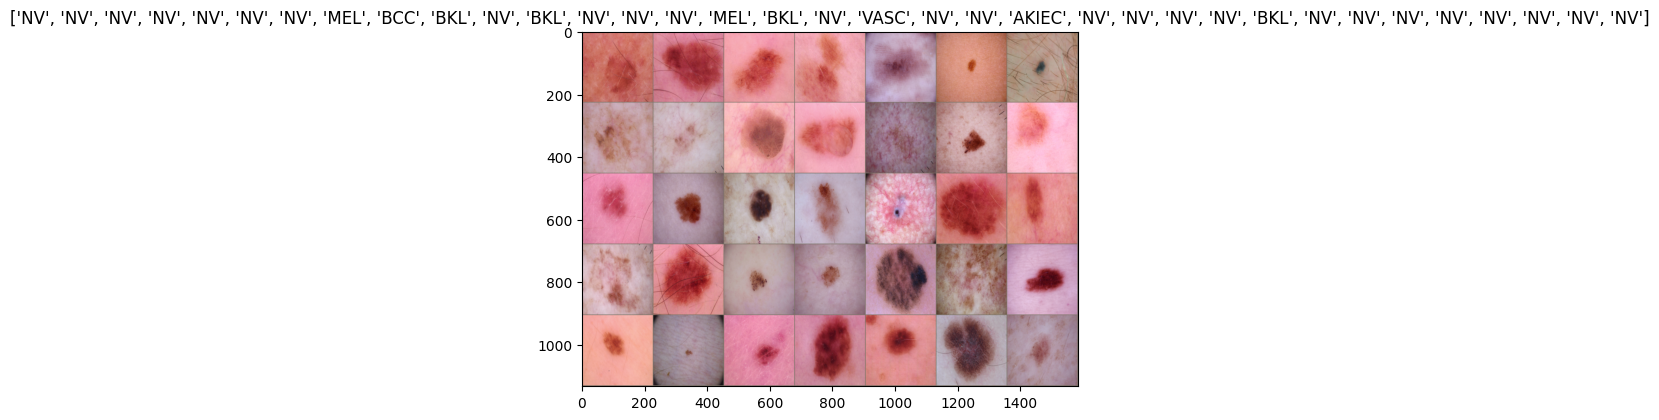

In [ ]:
# Visualize a few training images

def imshow(inp, title=None):
    """Display image for Tensor."""
    inp = inp.numpy().transpose((1, 2, 0))
    #undo normalization
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    plt.imshow(inp)
    if title is not None:
        plt.title(title)
    plt.pause(0.001)  # pause a bit so that plots are updated


# Get a batch of training data from base model
#inputs, classes = next(iter(dataloaders['train']))
inputs, classes = next(iter(train_loader_base_model))

# Make a grid from batch
out = torchvision.utils.make_grid(inputs, nrow=7)

imshow(out, title=[train_class_names[x] for x in classes])

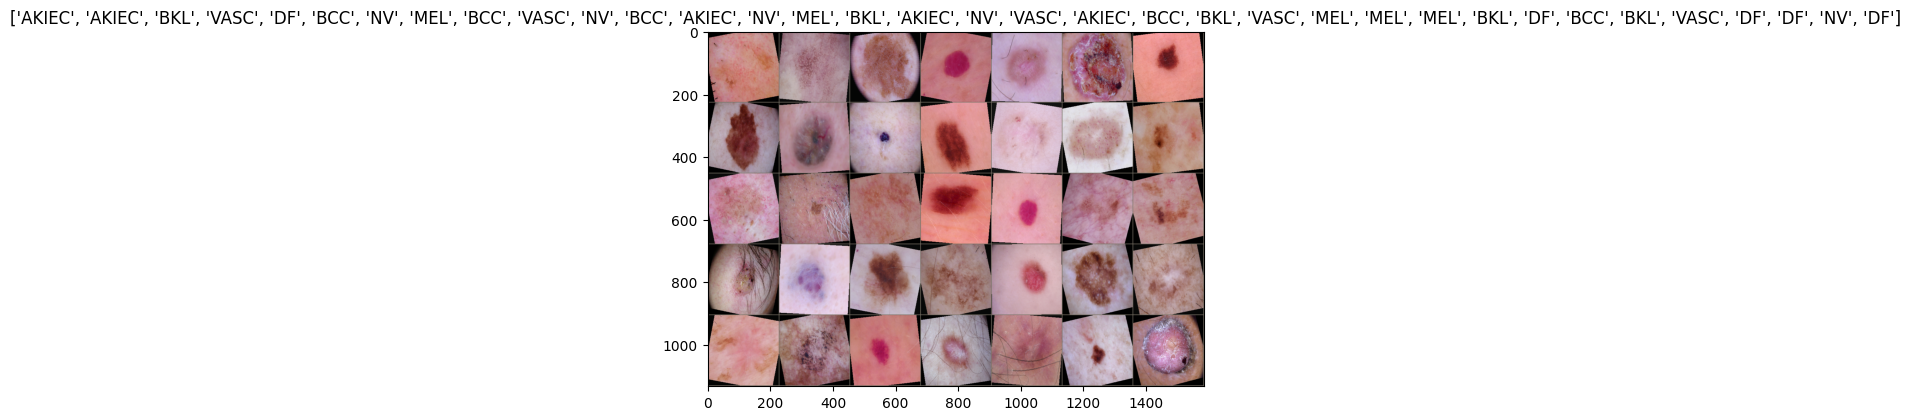

In [ ]:
# Get a batch of training data from v1 model
#inputs, classes = next(iter(dataloaders['train']))
inputs, classes = next(iter(train_loader_v1_model))

# Make a grid from batch
out = torchvision.utils.make_grid(inputs, nrow=7)

imshow(out, title=[train_class_names[x] for x in classes])

### Initialize the model. Model setup. Transfer learning

We will use **ResNet50 pretrained on imagenet**. First we download the weights and display the network architecture.

In [ ]:
from torchvision.models import resnet50, ResNet50_Weights
model = torchvision.models.resnet50(weights=ResNet50_Weights.DEFAULT)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 215MB/s]


In [ ]:
#print(model)

#print("First convolutional bloc")
#print(model.layer1) # First convolutional block

#print("Fianl fully connceted layer")
#print(model.fc) # Final fully connected layer

### Initialize model

In [ ]:
from torchvision.models import resnet50, ResNet50_Weights

# Model: ResNet Transfer Learning
# Load a pretrained model and reset final fully connected layer
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = torchvision.models.resnet50(weights=ResNet50_Weights.DEFAULT)

# Replace final fully connected layer.
num_ftrs = model.fc.in_features # model.fc is the final fully connected layer in ResNet. num_ftrs = model.fc.in_features = Size of input vector to fully connected layer
#model.fc = nn.Linear(num_ftrs, len(class_names)) # Replace fully connected layer; the size of each output sample is given by len(class_names)), i.e. the number of classes. (without dropout, used for base_model and v1_model)
model.fc = nn.Sequential(
    nn.Dropout(0.5),
    nn.Linear(num_ftrs, len(class_names))
) # dropout used when training last FC layer (used for v1_2_model and v2_model)
print(model.fc)

# model.fc is the final fully connected layer in ResNet.
# num_ftrs = number of input features to that layer.
# We replace it with a new layer that outputs len(class_names) units — one per class in our skin lesion dataset.

# Freeze all layers (i.e., disable training)
#for param in model.parameters():
#    param.requires_grad = False # freeze pretrained weights

# Unfreeze final layer (named fc)
#for param in model.fc.parameters():
#    param.requires_grad = True

# Unfreeze all layers for fine-tuning (all parameters are being optimized)
for param in model.parameters():
    param.requires_grad = True

# Put the model on the GPU
model = model.to(device)

# Loss function
criterion = nn.CrossEntropyLoss()
criterion_v2_model = nn.CrossEntropyLoss(weight=class_weights) # Initialize loss function with weights
#criterion_focal_loss = # define focal loss (in another notebook)

# Optimizer (with regularization (weight decay) for finetuning)
#optimizer_conv = optim.SGD(model.fc.parameters(), lr=0.001, momentum=0.9) # Only parameters of final layer are being optimized.
#optimizer_ft = optim.SGD(model.parameters(), lr=0.001, momentum=0.9) # All parameters are being optimized (no weight decay) (used for base_model and v1_model)
#optimizer_ft = optim.SGD(model.parameters(), lr=0.001, momentum=0.9, weight_decay=1e-4) # All parameters are being optimized (using weight decay) (used for v1_2_model and v2_model)
optimizer_ft = optim.SGD(model.parameters(), lr=5e-4, momentum=0.9, weight_decay=1e-4) # smaller learning rate

# Decay LR by a factor of 0.1 every 7 epochs
#exp_lr_scheduler_conv = lr_scheduler.StepLR(optimizer_conv, step_size=7, gamma=0.1)
exp_lr_scheduler_ft = lr_scheduler.StepLR(optimizer_ft, step_size=7, gamma=0.1)


Sequential(
  (0): Dropout(p=0.5, inplace=False)
  (1): Linear(in_features=2048, out_features=7, bias=True)
)


### Experiments with learning rate schedule (warmup + cosine decay)

Linear Warmup + Cosine learning rate scheduler

### Set up model, optimizer, and learning rate scheduler

In [ ]:
import torch
import torch.nn as nn
from torch.optim import SGD
from torch.optim.lr_scheduler import LambdaLR
import math
from tqdm import tqdm
import copy
import time


In [ ]:
# Define the warmup + cosine schedule
# Works per step, not per epoch.

def warmup_cosine_lambda(step, warmup_steps, total_steps):
    if step < warmup_steps:
        return step / float(max(1, warmup_steps))

    # Cosine schedule
    progress = (step - warmup_steps) / float(max(1, total_steps - warmup_steps))
    return 0.5 * (1.0 + math.cos(math.pi * progress))

### Main training function

In [ ]:
def train_model(
    model,
    dataloaders,
    criterion,
    optimizer,
    scheduler=None,
    num_epochs=10,
    device="cuda"
):
    since = time.time()
    best_model_wts = copy.deepcopy(model.state_dict())
    best_bal_acc = 0.0 # <- ISIC metric (balanced accuracy, macro average recall)

    # Compute total training steps
    train_steps_per_epoch = len(dataloaders["train"])
    total_steps = num_epochs * train_steps_per_epoch

    step = 0  # global optimizer step counter

    # Track history
    history = {
        'train_loss': [], 'val_loss': [],
        'train_acc': [], 'val_acc': [],
        'train_bal_acc': [], 'val_bal_acc': [],
        'train_f1': [], 'val_f1': [],
        'train_precision': [], 'val_precision': [],
        'train_recall': [], 'val_recall': []
    }

    lr_history = []
    step_indices = []

    for epoch in range(num_epochs):
        print(f"\nEpoch {epoch+1}/{num_epochs}")
        print("-" * 10)

        # Each epoch has a training and validation phase
        for phase in ["train", "val"]:
            if phase == "train":
                model.train() # set model to training mode
            else:
                model.eval() # set model to evaluation mode

            running_loss = 0.0
            running_corrects = 0
            all_preds, all_labels = [], []

            # Iterate over batches (data)
            for inputs, labels in tqdm(dataloaders[phase], desc=f"{phase.capitalize()}"):
                inputs = inputs.to(device)
                labels = labels.to(device)

                optimizer.zero_grad() # zero the parameter gradients

                # forward
                with torch.set_grad_enabled(phase == "train"):
                    outputs = model(inputs)
                    loss = criterion(outputs, labels)
                    _, preds = torch.max(outputs, 1)

                    # backward + optimize only if in training phase
                    if phase == "train":
                        loss.backward()
                        optimizer.step()

                        # per-step LR update
                        if scheduler is not None:
                            scheduler.step()
                            print(f"Current LR: {scheduler.get_last_lr()[0]:.6f}")

                        # record LR AFTER stepping the scheduler
                        # get_last_lr() returns list per param group — take group 0
                        current_lr = scheduler.get_last_lr()[0] # or optimizer.param_groups[0]['lr']
                        lr_history.append(current_lr)
                        step_indices.append(step)
                        step += 1

                # statistics
                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels) # running_corrects += torch.sum(preds == labels.data)

                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

            # Epoch metrics
            from sklearn.metrics import (
                f1_score, balanced_accuracy_score,
                precision_score, recall_score
            )

            epoch_loss = running_loss / len(dataloaders[phase].dataset)
            epoch_acc = running_corrects.double().item() / len(dataloaders[phase].dataset) # epoch_acc = running_corrects.double() / len(dataloaders[phase].dataset)
            epoch_f1 = f1_score(all_labels, all_preds, average="macro")
            epoch_bal_acc = balanced_accuracy_score(all_labels, all_preds)
            epoch_precision = precision_score(all_labels, all_preds, average="macro")
            epoch_recall = recall_score(all_labels, all_preds, average="macro")

            # Save history
            history[f"{phase}_loss"].append(epoch_loss)
            history[f"{phase}_acc"].append(epoch_acc)
            history[f"{phase}_f1"].append(epoch_f1)
            history[f"{phase}_bal_acc"].append(epoch_bal_acc)
            history[f"{phase}_precision"].append(epoch_precision)
            history[f"{phase}_recall"].append(epoch_recall)

            print(f"{phase.capitalize()} Loss: {epoch_loss:.4f} | "
                  f"Acc: {epoch_acc:.4f} | "
                  f"BalAcc: {epoch_bal_acc:.4f} | "
                  f"F1: {epoch_f1:.4f} | "
                  f"Precision: {epoch_precision:.4f} | "
                  f"Recall: {epoch_recall:.4f}")

            # Save best model based on Balanced Accuracy
            if phase == "val" and epoch_bal_acc > best_bal_acc:
                best_bal_acc = epoch_bal_acc
                best_model_wts = copy.deepcopy(model.state_dict())
                print(f"New best model! Balanced Acc = {best_bal_acc:.4f}")

    # Final summary
    total_time = time.time() - since
    print(f"\nTraining completed in {total_time//60:.0f}m {total_time%60:.0f}s")
    print(f"Best Val Balanced Accuracy: {best_bal_acc:.4f}")

    # Load best model weights
    model.load_state_dict(best_model_wts)
    return model, history, lr_history


### Learning rate scheduler

Uses a linear warmup of 1000 steps followed by cosine decay.

In [ ]:
num_epochs = 20
train_steps_per_epoch = len(dataloaders_v1_model["train"])
total_steps = num_epochs * train_steps_per_epoch
warmup_steps = 1000

optimizer_ft_lr = torch.optim.SGD(
    model.parameters(),
    lr=5e-4,
    momentum=0.9,
    weight_decay=1e-4
)

scheduler_linear_warmup = LambdaLR(
    optimizer_ft_lr,
    lr_lambda=lambda step: warmup_cosine_lambda(step, warmup_steps, total_steps)
)


### Run training

In [ ]:
v1_2_model_ft, v1_2_model_ft_history, v1_2_model_ft_lr_history = train_model(
    model=model,
    dataloaders=dataloaders_v1_model,
    criterion=criterion,
    optimizer=optimizer_ft_lr,
    scheduler=scheduler_linear_warmup,
    num_epochs=num_epochs,
    device=device
)

torch.save(v1_2_model_ft.state_dict(), "resnet50_best_balacc.pth")
print("Model saved.")


### Evaluate model

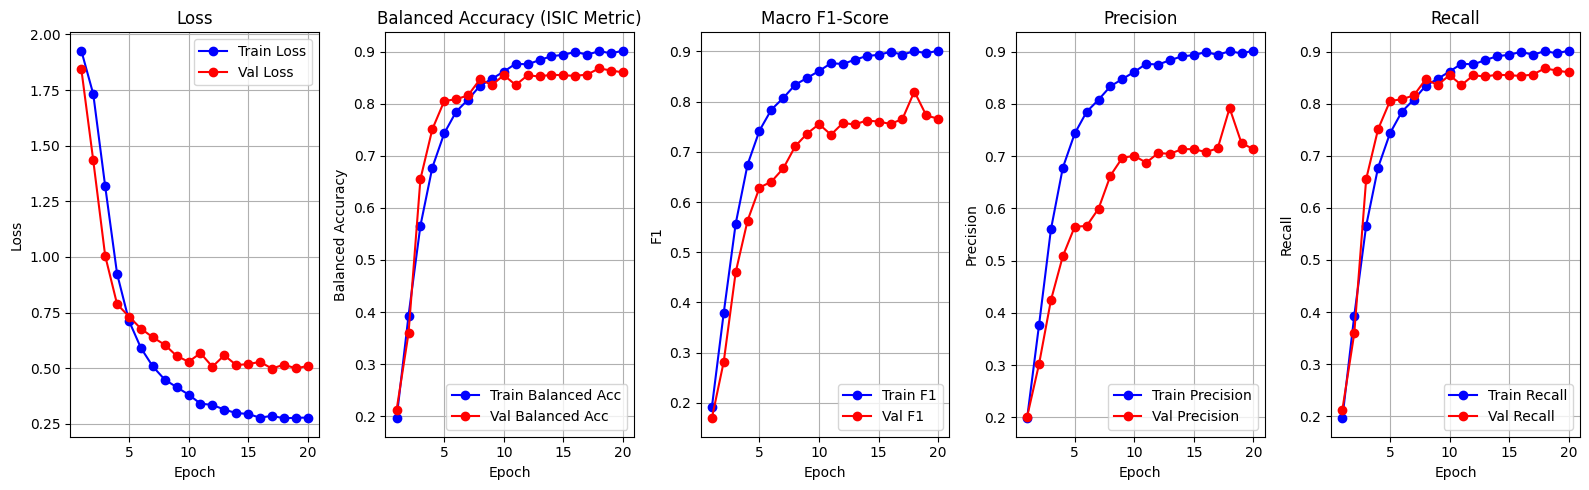

In [ ]:
# Plot evaluation metrics for training history
plot_training_history(v1_2_model_ft_history)

Evaluating Confusion Matrix: 100%|██████████| 6/6 [00:01<00:00,  3.50it/s]


              precision    recall  f1-score   support

         MEL       0.74      0.67      0.70        21
          NV       0.99      0.86      0.92       123
         BCC       0.64      0.93      0.76        15
       AKIEC       0.55      0.75      0.63         8
         BKL       0.63      0.86      0.73        22
          DF       1.00      1.00      1.00         1
        VASC       1.00      1.00      1.00         3

    accuracy                           0.84       193
   macro avg       0.79      0.87      0.82       193
weighted avg       0.88      0.84      0.85       193

Normalized confusion matrix


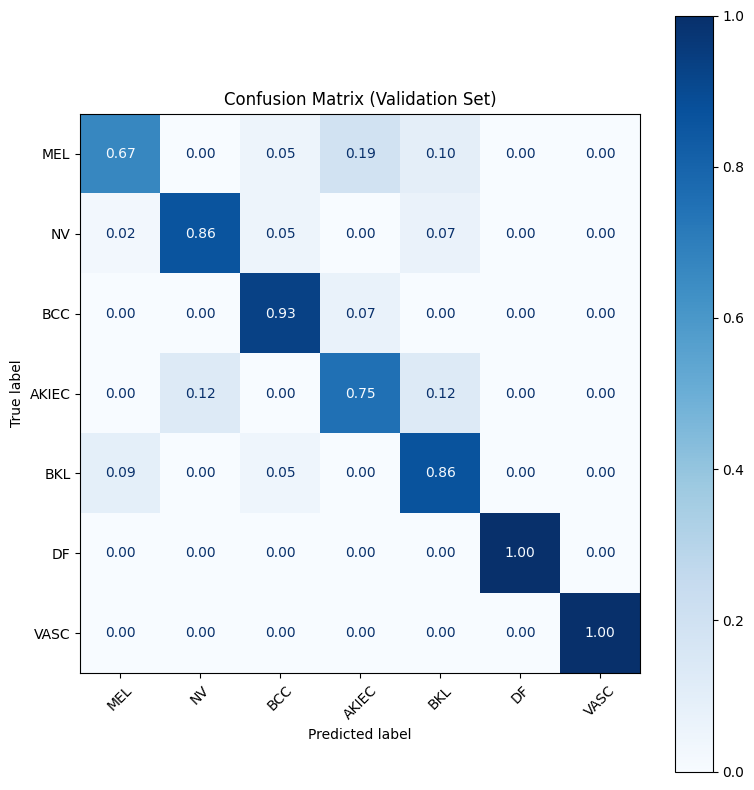

In [ ]:
# Evaluate performance on validation data and Plot confusion matrix
cm_v1_2_ft_val = evaluate_confusion_matrix(v1_2_model_ft, val_loader, class_names, device, normalize = True)

Evaluating Confusion Matrix: 100%|██████████| 6/6 [00:02<00:00,  2.70it/s]


              precision    recall  f1-score   support

         MEL       0.74      0.67      0.70        21
          NV       0.99      0.86      0.92       123
         BCC       0.64      0.93      0.76        15
       AKIEC       0.55      0.75      0.63         8
         BKL       0.63      0.86      0.73        22
          DF       1.00      1.00      1.00         1
        VASC       1.00      1.00      1.00         3

    accuracy                           0.84       193
   macro avg       0.79      0.87      0.82       193
weighted avg       0.88      0.84      0.85       193

Confusion matrix, without normalization


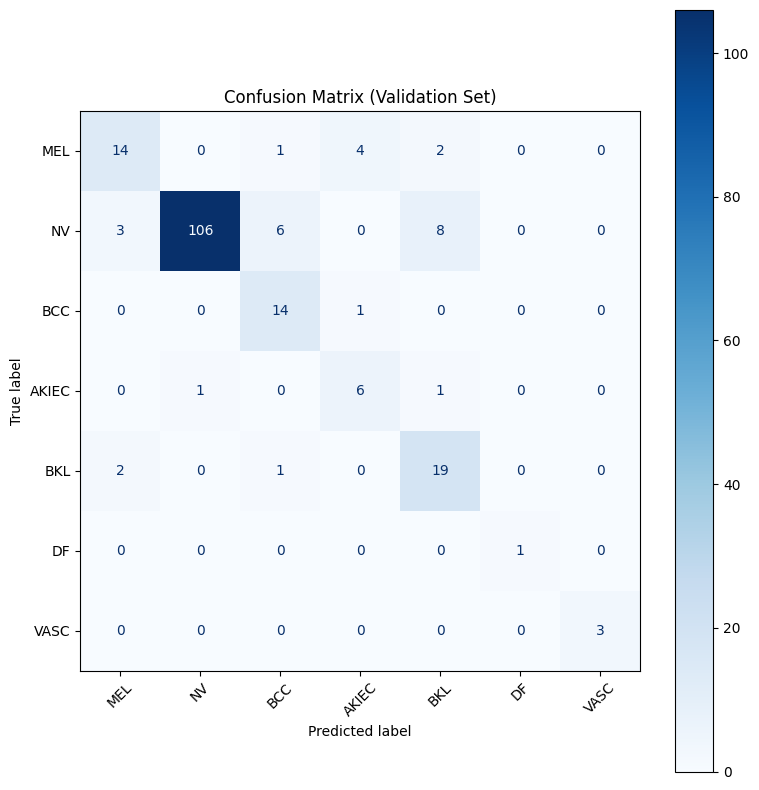

In [ ]:
cm_v1_2_ft_val = evaluate_confusion_matrix(v1_2_model_ft, val_loader, class_names, device, normalize = False)

Evaluating Confusion Matrix: 100%|██████████| 44/44 [00:12<00:00,  3.43it/s]


              precision    recall  f1-score   support

         MEL       0.48      0.64      0.55       171
          NV       0.96      0.80      0.87       909
         BCC       0.73      0.70      0.71        93
       AKIEC       0.44      0.74      0.56        43
         BKL       0.58      0.75      0.65       217
          DF       0.70      0.68      0.69        44
        VASC       0.75      0.86      0.80        35

    accuracy                           0.76      1512
   macro avg       0.66      0.74      0.69      1512
weighted avg       0.81      0.76      0.78      1512

Normalized confusion matrix


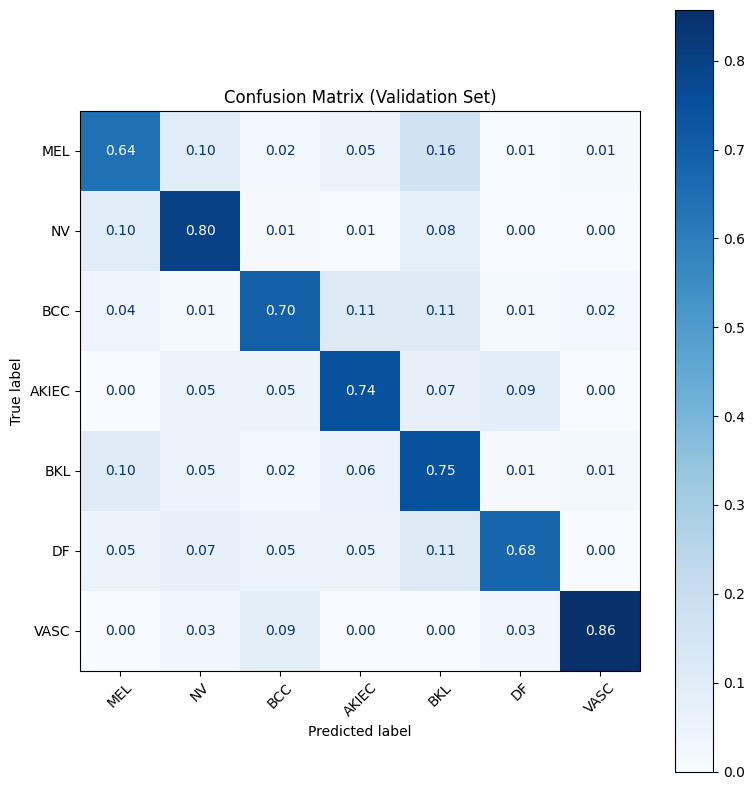

In [ ]:
# Evaluate performance on test data and Plot confusion matrix
cm_v1_2_ft_test = evaluate_confusion_matrix(v1_2_model_ft, test_loader, class_names, device, normalize = True)

Evaluating Confusion Matrix: 100%|██████████| 44/44 [00:12<00:00,  3.40it/s]


              precision    recall  f1-score   support

         MEL       0.48      0.64      0.55       171
          NV       0.96      0.80      0.87       909
         BCC       0.73      0.70      0.71        93
       AKIEC       0.44      0.74      0.56        43
         BKL       0.58      0.75      0.65       217
          DF       0.70      0.68      0.69        44
        VASC       0.75      0.86      0.80        35

    accuracy                           0.76      1512
   macro avg       0.66      0.74      0.69      1512
weighted avg       0.81      0.76      0.78      1512

Confusion matrix, without normalization


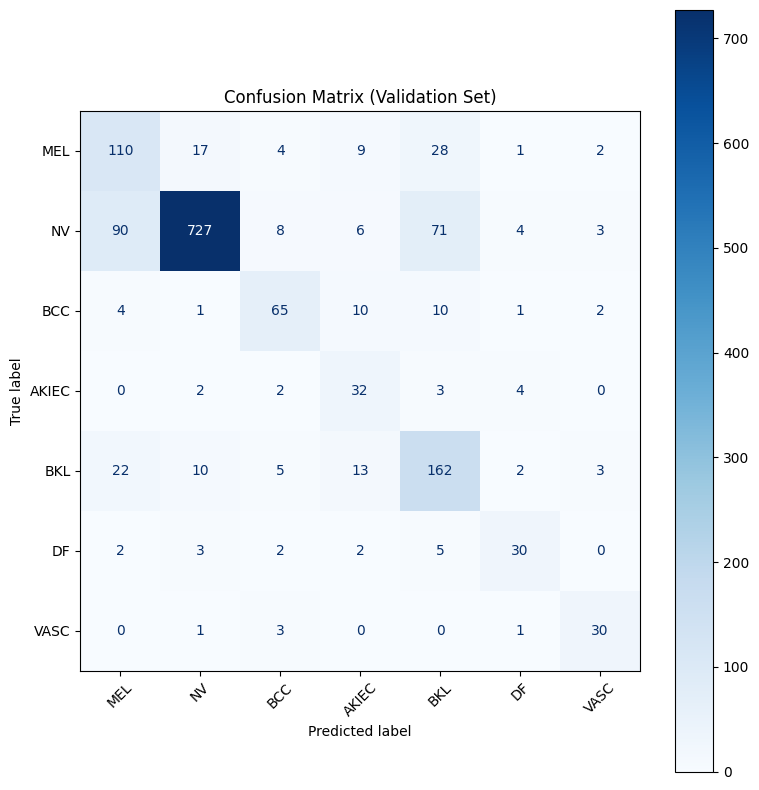

In [ ]:
cm_v1_2_ft_test = evaluate_confusion_matrix(v1_2_model_ft, test_loader, class_names, device, normalize = False)

Computing per-image losses: 100%|██████████| 44/44 [00:13<00:00,  3.22it/s]


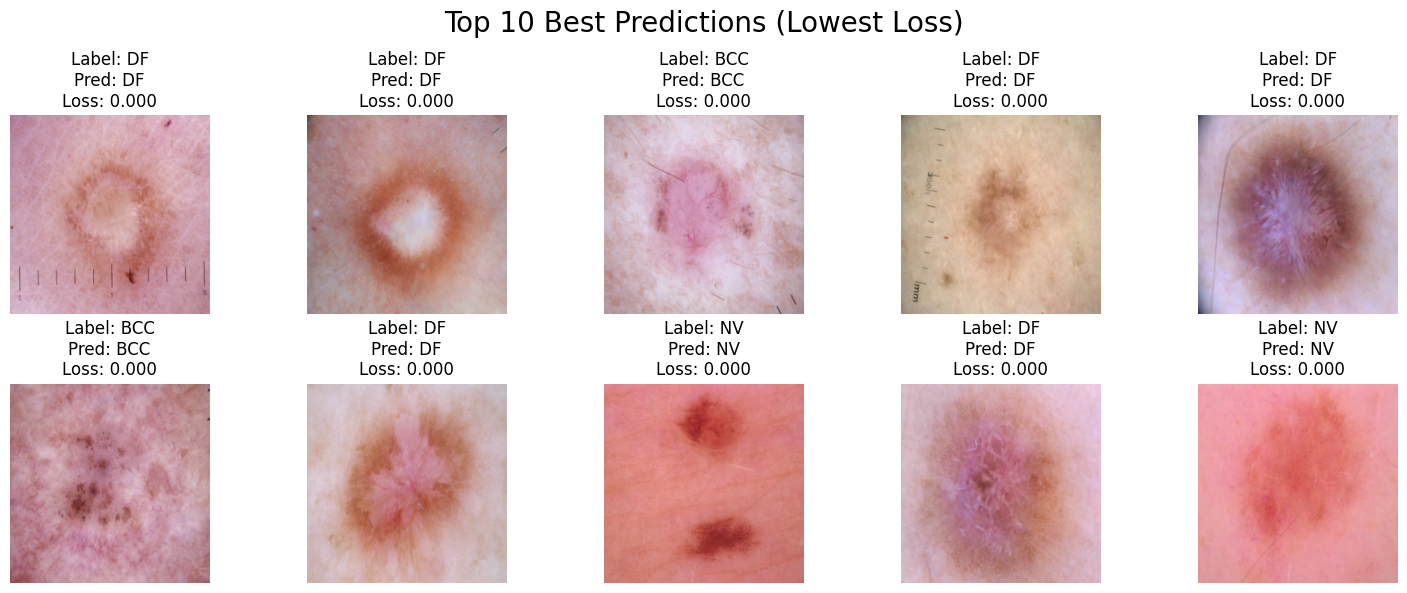

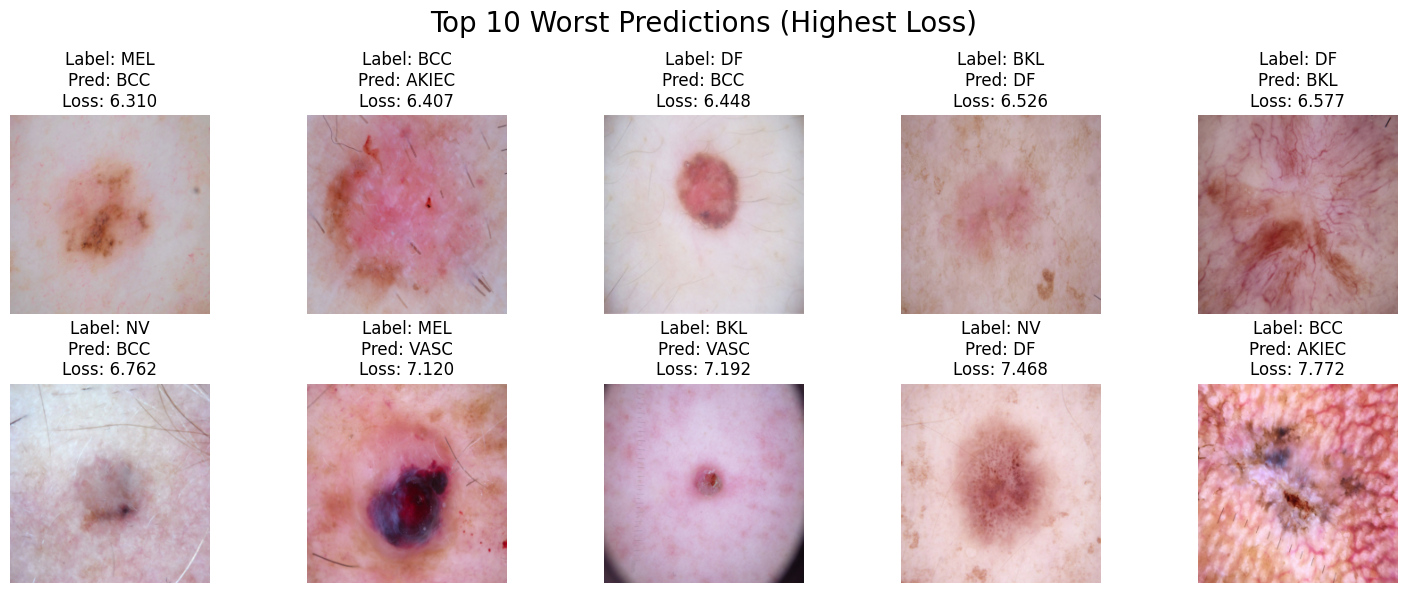

In [ ]:
# Display the top/bottom 10 images in your test set (e.g., those with the lowest/highest loss)
per_image_info = get_per_image_losses(model, test_loader, device="cuda")
lowest_loss, highest_loss = get_best_and_worst(per_image_info, k=10)
show_images(lowest_loss, class_names, "Top 10 Best Predictions (Lowest Loss)")
show_images(highest_loss, class_names, "Top 10 Worst Predictions (Highest Loss)")

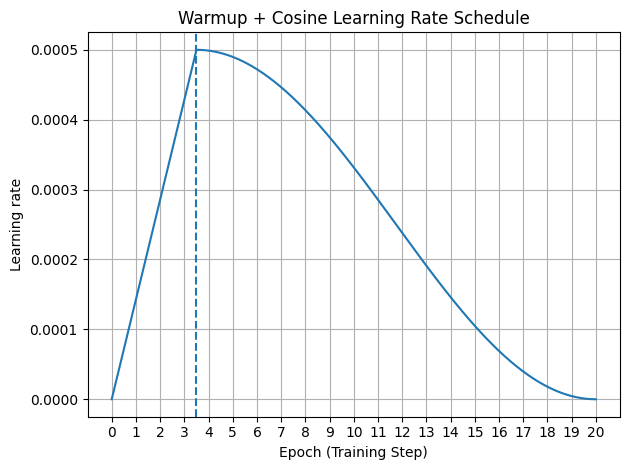

In [ ]:
# Plot learning rate

import matplotlib.pyplot as plt
import numpy as np
import math

def warmup_cosine_lambda(step, warmup_steps, total_steps):
    if step < warmup_steps:
        return step / float(max(1, warmup_steps))
    progress = (step - warmup_steps) / float(max(1, total_steps - warmup_steps))
    return 0.5 * (1.0 + math.cos(math.pi * progress))

def get_lr(step, max_lr, warmup_steps, total_steps):
    return max_lr * warmup_cosine_lambda(step, warmup_steps, total_steps)

#steps_per_epoch = 286 # len(dataloaders['train'])
#epochs = 20
#total_steps = steps_per_epoch * epochs = 20 * 286 = 5720

#Warmup: 0 → 999
#Cosine decay: 1000 → 5719

#Generate Step Indices + LR Values (For Plotting)
warmup_steps = 1000
total_steps = 5720
max_lr = 5e-4

steps = np.arange(total_steps)
lrs = [get_lr(step, max_lr, warmup_steps, total_steps) for step in steps]

#fig, ax = plt.subplots(figsize=(10, 4))
fig, ax = plt.subplots()
ax.plot(steps, lrs)                       # no explicit color

# Put epoch ticks: one tick per epoch at step = epoch * steps_per_epoch
steps_per_epoch = 286
num_epochs = (steps.max() // steps_per_epoch) + 1 # 20
epoch_ticks = [e * steps_per_epoch for e in range(num_epochs + 1)]
epoch_labels = [str(e) for e in range(num_epochs + 1)]

ax.set_xticks(epoch_ticks)
ax.set_xticklabels(epoch_labels)
ax.set_xlabel('Epoch (Training Step)')
ax.set_ylabel('Learning rate')
ax.set_title("Warmup + Cosine Learning Rate Schedule")
plt.axvline(warmup_steps, linestyle='--')
ax.grid(True)

plt.tight_layout()
plt.show()


#plt.figure()
#plt.plot(steps, lrs)
#plt.axvline(warmup_steps, linestyle='--')
#plt.title("Warmup + Cosine Learning Rate Schedule")
#plt.xlabel("Training Step")
#plt.ylabel("Learning Rate")
#plt.grid(True)
#plt.show()

In [ ]:
len(dataloaders_v1_model['train'])

286

In [ ]:
# Make Grad-Cam heatmaps - validation data

target_layer = v1_2_model_ft.layer4[-1]  # last conv block for ResNet50

generate_and_save_gradcams_side_by_side(
    model=v1_2_model_ft,
    dataloader=val_loader,
    target_layer=target_layer,
    class_names=class_names,
    save_dir="gradcams_side_by_side_v1_2_model_val_data",
    max_batches=6,
    device=device
)


In [ ]:
# Make Grad-Cam heatmaps - test data

target_layer = v1_2_model_ft.layer4[-1]  # last conv block for ResNet50

generate_and_save_gradcams_side_by_side(
    model=v1_2_model_ft,
    dataloader=test_loader,
    target_layer=target_layer,
    class_names=class_names,
    save_dir="gradcams_side_by_side_v1_2_model_test_data",
    max_batches=44,
    device=device
)


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:1866: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


Saved batch 0 (35 images).
Saved batch 1 (35 images).
Saved batch 2 (35 images).
Saved batch 3 (35 images).
Saved batch 4 (35 images).
Saved batch 5 (35 images).
Saved batch 6 (35 images).
Saved batch 7 (35 images).
Saved batch 8 (35 images).
Saved batch 9 (35 images).
Saved batch 10 (35 images).
Saved batch 11 (35 images).
Saved batch 12 (35 images).
Saved batch 13 (35 images).
Saved batch 14 (35 images).
Saved batch 15 (35 images).
Saved batch 16 (35 images).
Saved batch 17 (35 images).
Saved batch 18 (35 images).
Saved batch 19 (35 images).
Saved batch 20 (35 images).
Saved batch 21 (35 images).
Saved batch 22 (35 images).
Saved batch 23 (35 images).
Saved batch 24 (35 images).
Saved batch 25 (35 images).
Saved batch 26 (35 images).
Saved batch 27 (35 images).
Saved batch 28 (35 images).
Saved batch 29 (35 images).
Saved batch 30 (35 images).
Saved batch 31 (35 images).
Saved batch 32 (35 images).
Saved batch 33 (35 images).
Saved batch 34 (35 images).
Saved batch 35 (35 images).
Sa

### Set up general training function

In [ ]:
# General function to train model

def train_model(model, dataloaders, criterion, optimizer, scheduler=None, num_epochs=10, device='cuda'):
    since = time.time()

    # Copy weights
    best_model_wts = copy.deepcopy(model.state_dict())
    best_bal_acc = 0.0  # <-- ISIC metric (balanced accuracy)

    # Track history
    history = {
        'train_loss': [], 'val_loss': [],
        'train_acc': [], 'val_acc': [],
        'train_bal_acc': [], 'val_bal_acc': [],
        'train_f1': [], 'val_f1': [],
        'train_precision': [], 'val_precision': [],
        'train_recall': [], 'val_recall': []
    }

    for epoch in range(num_epochs):
        print(f"\nEpoch {epoch+1}/{num_epochs}")
        print('-' * 10)

        # Each epoch has a training and validation phase
        for phase in ['train', 'val']:
            if phase == 'train':
                model.train() # set model to training mode
                if scheduler is not None:
                    scheduler.step()
            else:
                model.eval() # set model to evaluation mode

            running_loss = 0.0
            running_corrects = 0
            all_preds, all_labels = [], []

            # Iterate over batches (data)
            for inputs, labels in tqdm(dataloaders[phase], desc=f"{phase.capitalize()}"):
                inputs, labels = inputs.to(device), labels.to(device)
                optimizer.zero_grad() # zero the parameter gradients

                # forward
                # track history only if in train
                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    # backward + optimize only if in training phase
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                # statistics
                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

            # Epoch metrics
            epoch_loss = running_loss / len(dataloaders[phase].dataset)
            epoch_acc = running_corrects.double() / len(dataloaders[phase].dataset)
            epoch_f1 = f1_score(all_labels, all_preds, average='macro')
            epoch_bal_acc = balanced_accuracy_score(all_labels, all_preds)
            epoch_precision = precision_score(all_labels, all_preds, average='macro')
            epoch_recall = recall_score(all_labels, all_preds, average='macro')

            history[f'{phase}_loss'].append(epoch_loss)
            history[f'{phase}_acc'].append(epoch_acc.item())
            history[f'{phase}_f1'].append(epoch_f1)
            history[f'{phase}_bal_acc'].append(epoch_bal_acc)
            history[f'{phase}_precision'].append(epoch_precision)
            history[f'{phase}_recall'].append(epoch_recall)

            print(f"{phase.capitalize()} Loss: {epoch_loss:.4f} | "
                  f"Acc: {epoch_acc:.4f} | "
                  f"BalAcc: {epoch_bal_acc:.4f} | "
                  f"F1: {epoch_f1:.4f} | "
                  f"Precision: {epoch_precision:.4f} | "
                  f"Recall: {epoch_recall:.4f}")

            # Save best model based on Balanced Accuracy
            if phase == 'val' and epoch_bal_acc > best_bal_acc:
                best_bal_acc = epoch_bal_acc
                best_model_wts = copy.deepcopy(model.state_dict())
                print(f"New best model found! (Balanced Acc = {best_bal_acc:.4f})")

    # Final summary
    time_elapsed = time.time() - since
    print(f"\nTraining complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s")
    print(f"Best validation balanced accuracy: {best_bal_acc:.4f}")

    # Load best model weights
    model.load_state_dict(best_model_wts)
    return model, history


### Train and evaluate base model

In [ ]:
# Training & Validation of base model with metrics tracking

base_model, base_model_history = train_model(
    model=model,
    dataloaders=dataloaders_base_model,
    criterion=criterion,
    optimizer=optimizer_conv,
    scheduler=exp_lr_scheduler_conv,
    num_epochs=5,
    device=device
)

torch.save(base_model.state_dict(), "resnet50_skin_lesion_base_model_best_balacc.pth")
print("Model saved as resnet50_skin_lesion_base_model_best_balacc.pth")

Plots

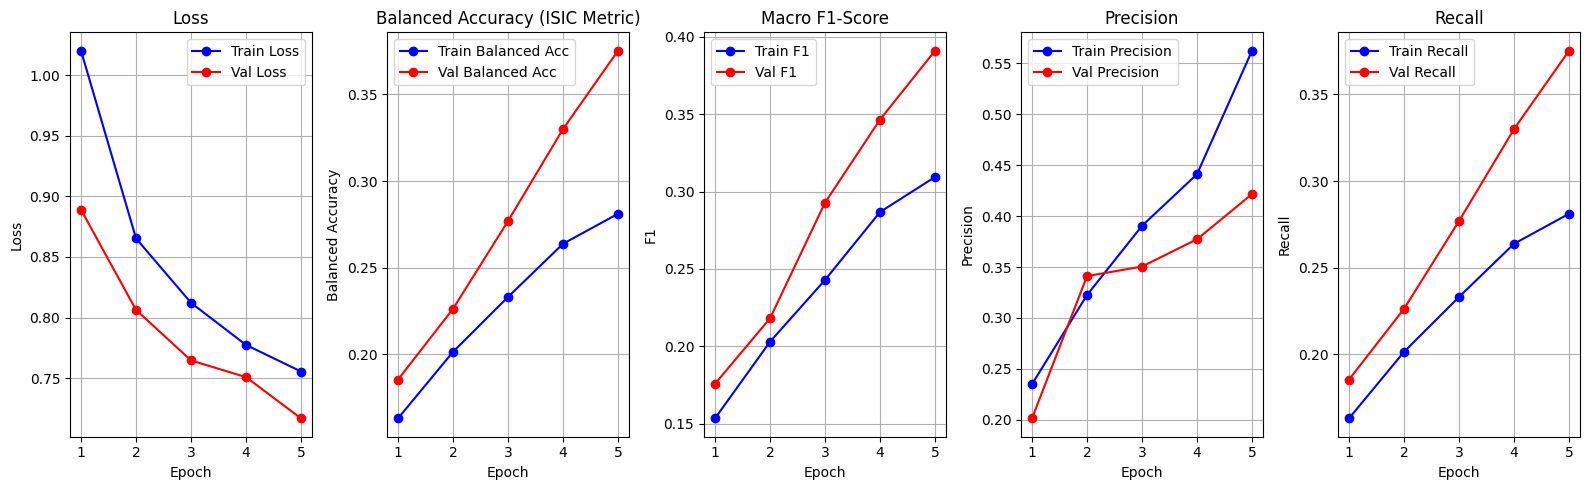

In [ ]:
plot_training_history(base_model_history)

Evaluating Confusion Matrix: 100%|██████████| 6/6 [00:01<00:00,  3.64it/s]
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capita

              precision    recall  f1-score   support

         MEL       0.67      0.48      0.56        21
          NV       0.82      0.96      0.88       123
         BCC       0.90      0.60      0.72        15
       AKIEC       0.00      0.00      0.00         8
         BKL       0.57      0.59      0.58        22
          DF       0.00      0.00      0.00         1
        VASC       0.00      0.00      0.00         3

    accuracy                           0.78       193
   macro avg       0.42      0.38      0.39       193
weighted avg       0.73      0.78      0.75       193

Normalized confusion matrix


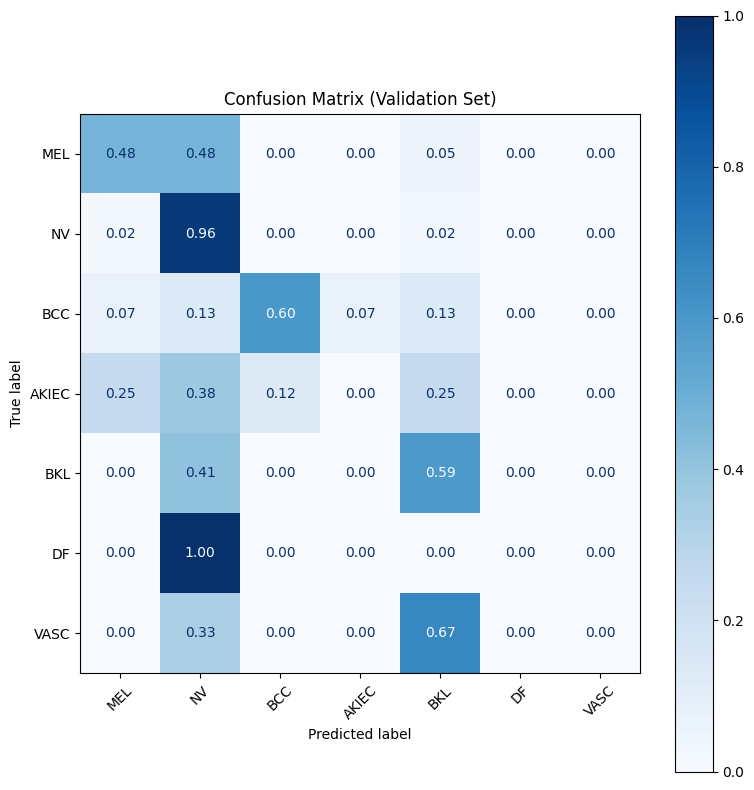

In [ ]:
cm = evaluate_confusion_matrix(base_model, val_loader, class_names, device, normalize = True)
#cm = evaluate_confusion_matrix(base_model, val_loader, class_names, device, normalize = False)

### Train and evaluate v1 model (balanced batch sampler)

In [ ]:
# Training & Validation of v1 model with metrics tracking
# data augmentation, balanced batch sampler (no weight decay or dropout)

v1_model_ft, v1_model_ft_history = train_model(
    model=model,
    dataloaders=dataloaders_v1_model,
    criterion=criterion,
    optimizer=optimizer_ft,
    scheduler=exp_lr_scheduler_ft,
    num_epochs=10,
    device=device
)

torch.save(v1_model_ft.state_dict(), "resnet50_skin_lesion_v1_model_ft_best_balacc.pth")
print("Model saved as resnet50_skin_lesion_v1_model_ft_best_balacc.pth")

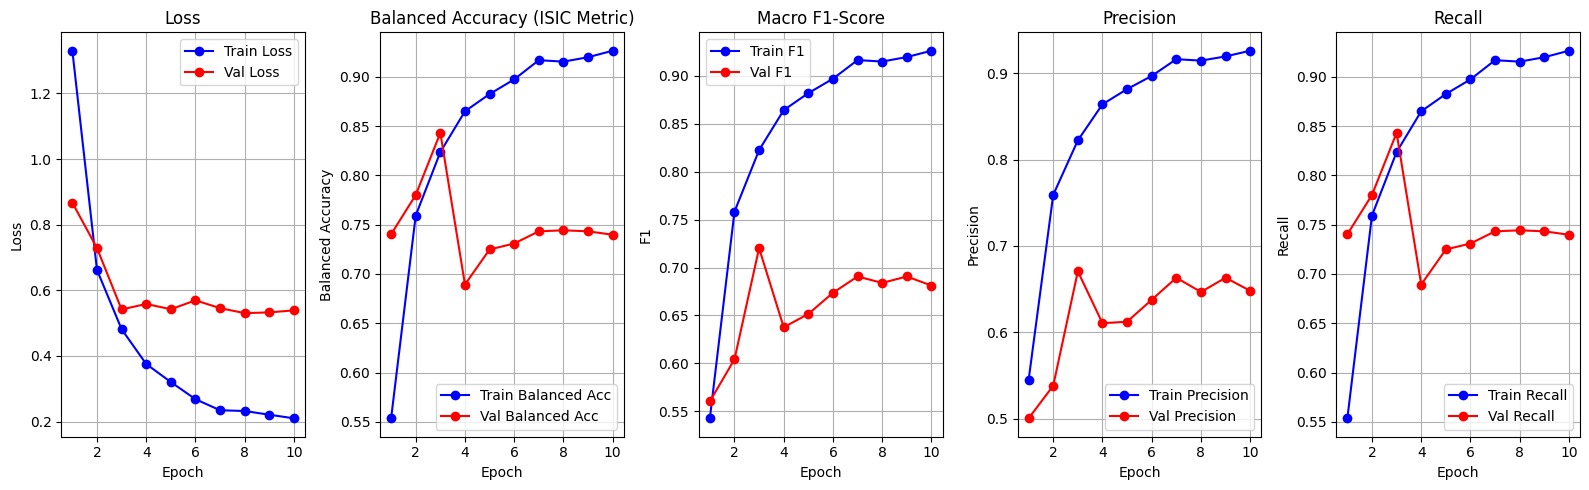

In [ ]:
# Plot evaluation metrics
plot_training_history(v1_model_ft_history)

Evaluating Confusion Matrix: 100%|██████████| 6/6 [00:01<00:00,  3.49it/s]


              precision    recall  f1-score   support

         MEL       0.64      0.67      0.65        21
          NV       0.99      0.85      0.91       123
         BCC       0.62      0.87      0.72        15
       AKIEC       0.38      0.75      0.50         8
         BKL       0.74      0.77      0.76        22
          DF       0.33      1.00      0.50         1
        VASC       1.00      1.00      1.00         3

    accuracy                           0.82       193
   macro avg       0.67      0.84      0.72       193
weighted avg       0.87      0.82      0.83       193

Normalized confusion matrix


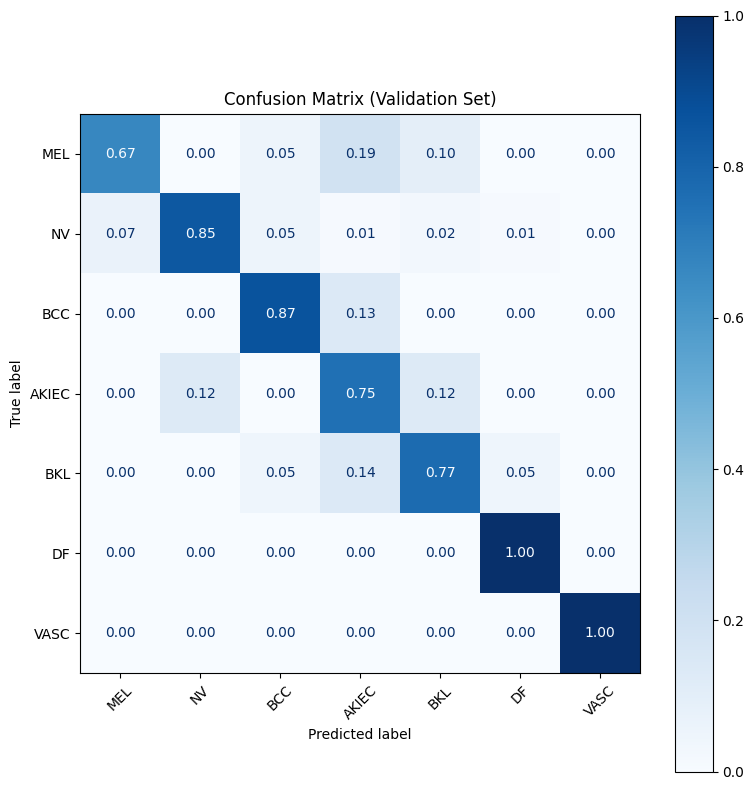

In [ ]:
# Plot confusion matrix
cm_v1 = evaluate_confusion_matrix(v1_model_ft, val_loader, class_names, device, normalize = True)

Evaluating Confusion Matrix: 100%|██████████| 6/6 [00:01<00:00,  3.66it/s]


              precision    recall  f1-score   support

         MEL       0.64      0.67      0.65        21
          NV       0.99      0.85      0.91       123
         BCC       0.62      0.87      0.72        15
       AKIEC       0.38      0.75      0.50         8
         BKL       0.74      0.77      0.76        22
          DF       0.33      1.00      0.50         1
        VASC       1.00      1.00      1.00         3

    accuracy                           0.82       193
   macro avg       0.67      0.84      0.72       193
weighted avg       0.87      0.82      0.83       193

Confusion matrix, without normalization


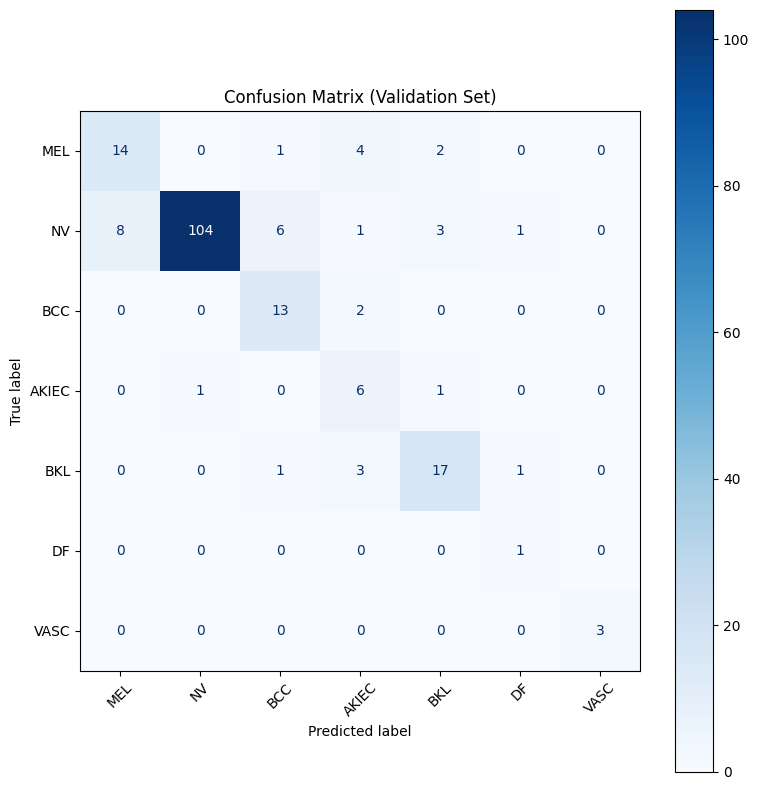

In [ ]:
cm_v1 = evaluate_confusion_matrix(v1_model_ft, val_loader, class_names, device, normalize = False)

### Train and evaluate v1.2 model -> v1 model + regularization to reduce overfitting -> Grad-CAM visualization
v1.2 model = v1 model (same data augmentation + balanced batch sampler) with L2 regularization term added to cross entropy loss function and dropout used when training last FC layer)

In [ ]:
# Training & Validation of v1_2 model with metrics tracking
# all layers unfreezed = finetuning

v1_2_model_ft, v1_2_model_ft_history = train_model(
    model=model,
    dataloaders=dataloaders_v1_model,
    criterion=criterion,
    optimizer=optimizer_ft,
    scheduler=exp_lr_scheduler_ft,
    num_epochs=10,
    device=device
)

torch.save(v1_2_model_ft.state_dict(), "resnet50_skin_lesion_v1_2_model_ft_best_balacc.pth")
print("Model saved as resnet50_skin_lesion_v1_2_model_ft_best_balacc.pth")

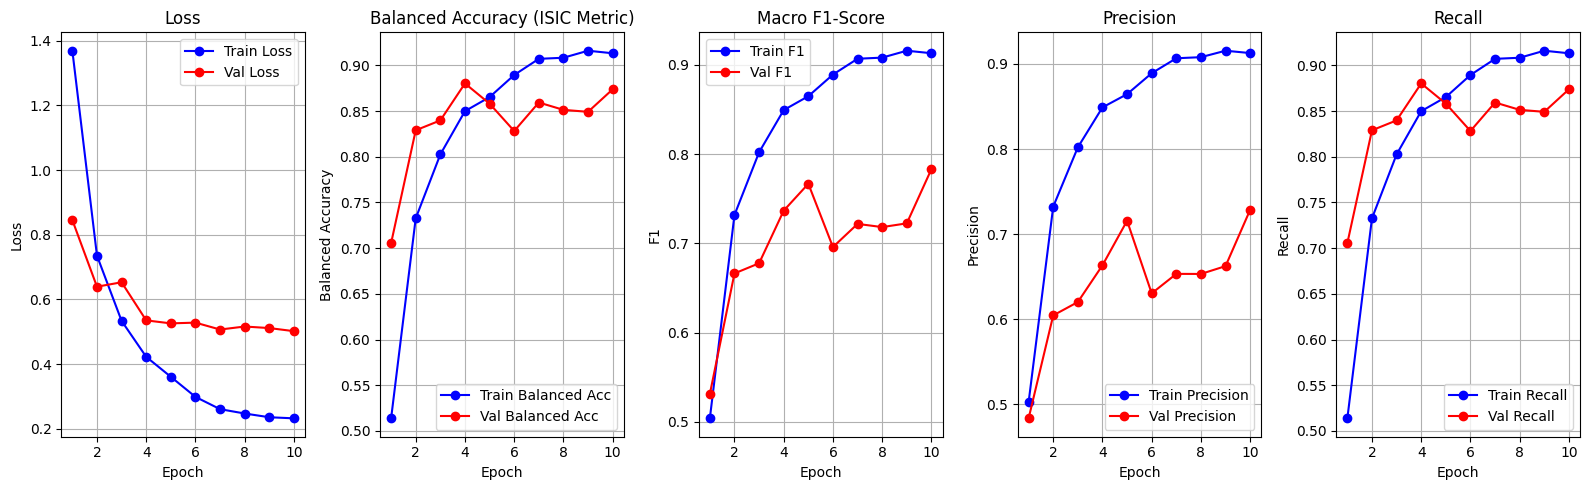

In [ ]:
# Plot evaluation metrics
plot_training_history(v1_2_model_ft_history)

Evaluating Confusion Matrix: 100%|██████████| 6/6 [00:01<00:00,  3.34it/s]


              precision    recall  f1-score   support

         MEL       0.60      0.71      0.65        21
          NV       0.99      0.82      0.90       123
         BCC       0.67      0.93      0.78        15
       AKIEC       0.64      0.88      0.74         8
         BKL       0.67      0.82      0.73        22
          DF       0.33      1.00      0.50         1
        VASC       0.75      1.00      0.86         3

    accuracy                           0.82       193
   macro avg       0.66      0.88      0.74       193
weighted avg       0.86      0.82      0.83       193

Normalized confusion matrix


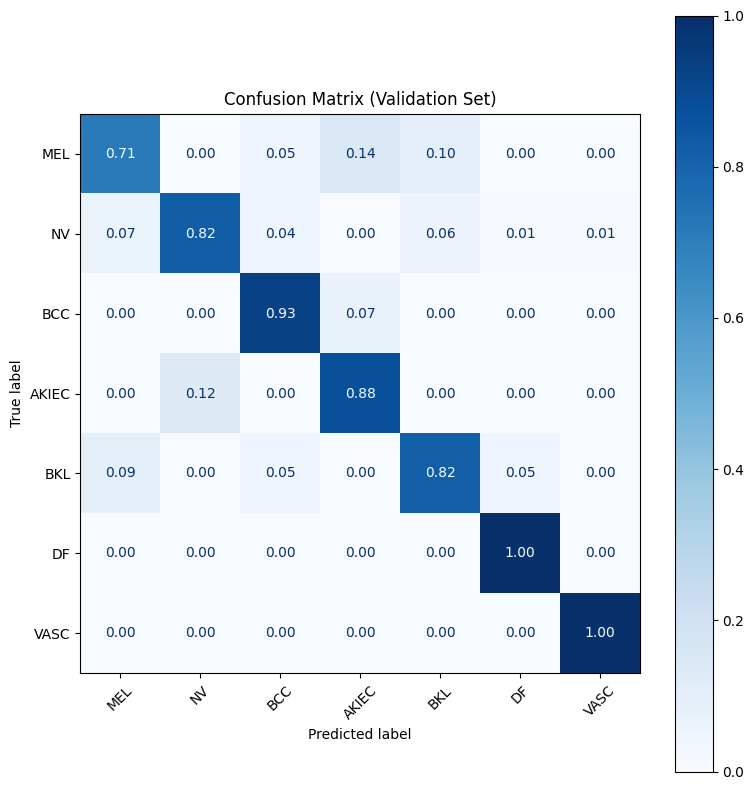

In [ ]:
# Plot confusion matrix-
cm_v1_2_ft = evaluate_confusion_matrix(v1_2_model_ft, val_loader, class_names, device, normalize = True)

Evaluating Confusion Matrix: 100%|██████████| 6/6 [00:01<00:00,  3.32it/s]


              precision    recall  f1-score   support

         MEL       0.60      0.71      0.65        21
          NV       0.99      0.82      0.90       123
         BCC       0.67      0.93      0.78        15
       AKIEC       0.64      0.88      0.74         8
         BKL       0.67      0.82      0.73        22
          DF       0.33      1.00      0.50         1
        VASC       0.75      1.00      0.86         3

    accuracy                           0.82       193
   macro avg       0.66      0.88      0.74       193
weighted avg       0.86      0.82      0.83       193

Confusion matrix, without normalization


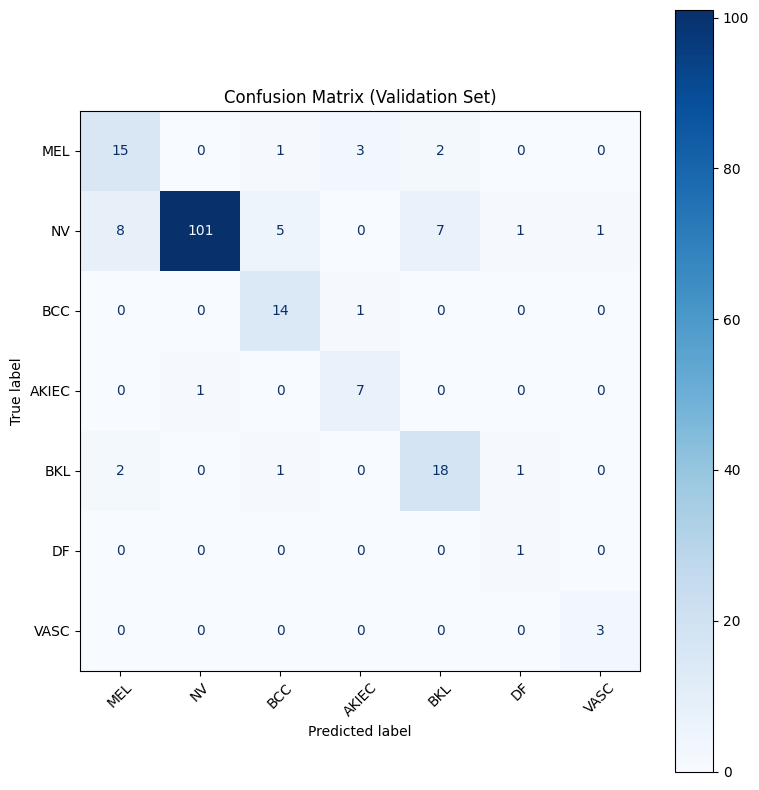

In [ ]:
cm_v1_2_ft = evaluate_confusion_matrix(v1_2_model_ft, val_loader, class_names, device, normalize = False)

In [ ]:
# Grad-CAM + side-by-side saving
import torch
import torch.nn.functional as F
import numpy as np
import cv2
from pathlib import Path
from PIL import Image

#GradCAM class (hook-based) 
class GradCAM:
    """
    Hook-based Grad-CAM for a single target convolutional module.
    Usage:
      gradcam = GradCAM(model, target_layer_module)
      cam = gradcam.generate(input_tensor, target_class=pred_idx)  # cam is HxW normalized 0..1
      gradcam.remove_hooks()
    """
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.activations = None
        self.gradients = None
        self.hooks = []
        self._register_hooks()

    def _register_hooks(self):
        # forward hook saves the activations (feature maps) from target layer
        def forward_hook(module, input, output):
            # output: (B, C, H, W)
            self.activations = output.detach()

        # backward hook saves gradients w.r.t. the activations
        def backward_hook(module, grad_input, grad_output):
            # grad_output[0] has shape (B, C, H, W)
            self.gradients = grad_output[0].detach()

        # Register hooks and store handles so we can remove them later
        self.hooks.append(self.target_layer.register_forward_hook(forward_hook))
        self.hooks.append(self.target_layer.register_backward_hook(backward_hook))

    def remove_hooks(self):
        for h in self.hooks:
            h.remove()
        self.hooks = []

    def generate(self, input_tensor, target_class=None):
        """
        input_tensor: (1, C, H_in, W_in), preprocessed as used during training
        target_class: int or None (if None, uses model's predicted class)
        returns: heatmap numpy (H_feat, W_feat) normalized 0..1 (size = feature map size)
        """
        self.model.eval()
        # forward pass
        outputs = self.model(input_tensor)  # shape (1, num_classes)
        if target_class is None:
            target_class = int(outputs.argmax(dim=1).item())

        # zero grads and do backward on the chosen class score (logit preferred)
        self.model.zero_grad()
        class_score = outputs[0, target_class]
        class_score.backward(retain_graph=False)

        # get saved activations and gradients
        activations = self.activations  # (1, C, Hf, Wf)
        gradients = self.gradients      # (1, C, Hf, Wf)
        if activations is None or gradients is None:
            raise RuntimeError("Gradients or activations not captured — check target_layer is part of forward pass.")

        # 1) Global average pooling of gradients -> channel importance weights
        #    pooled: shape (1, C, 1, 1)
        pooled = gradients.mean(dim=(2, 3), keepdim=True)

        # 2) Weight the channels by these importance weights and sum over channels
        #    (1, C, Hf, Wf) * (1, C, 1, 1) -> (1, C, Hf, Wf) -> sum -> (1, 1, Hf, Wf)
        weighted = activations * pooled
        cam = weighted.sum(dim=1, keepdim=True)  # (1, 1, Hf, Wf)

        # 3) ReLU (only positive evidence)
        cam = F.relu(cam)

        # 4) Squeeze and normalize to [0,1]
        cam = cam.squeeze(0).squeeze(0)  # (Hf, Wf)
        cam_np = cam.cpu().numpy()
        cam_np = (cam_np - cam_np.min()) / (cam_np.max() - cam_np.min() + 1e-8)

        return cam_np


# Utilities: undo normalization, colorize, overlay, side-by-side 
def tensor_to_uint8_img(img_tensor):
    """
    Convert a normalized torch image tensor (C,H,W) to uint8 RGB (H,W,3).
    Assumes normalization with mean=[0.485,0.456,0.406] and std=[0.229,0.224,0.225].
    """
    # move to cpu and HWC
    img = img_tensor.cpu().permute(1, 2, 0).numpy()
    # denormalize
    img = img * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
    img = np.clip(img, 0, 1)
    img_uint8 = (img * 255).astype(np.uint8)
    # convert RGB to BGR for cv2 (cv2 expects BGR)
    img_bgr = cv2.cvtColor(img_uint8, cv2.COLOR_RGB2BGR)
    return img_bgr


def colorize_cam(cam, target_size):
    """
    cam: numpy (Hf, Wf) in [0,1]
    target_size: (W_img, H_img) target size to resize to
    returns: BGR uint8 heatmap sized to target_size
    """
    # Resize heatmap to image size (bilinear)
    H_img, W_img = target_size[1], target_size[0]
    cam_resized = cv2.resize(cam, (W_img, H_img), interpolation=cv2.INTER_LINEAR)
    heatmap = np.uint8(255 * cam_resized)
    # Apply color map (JET)
    heatmap_color = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)  # BGR uint8
    return heatmap_color


def overlay_heatmap_on_image(img_bgr, heatmap_bgr, alpha=0.4):
    """
    img_bgr: uint8 BGR image (H,W,3)
    heatmap_bgr: uint8 BGR heatmap (H,W,3)
    alpha: blending factor
    returns: overlay BGR uint8
    """
    overlay = cv2.addWeighted(heatmap_bgr, alpha, img_bgr, 1 - alpha, 0)
    return overlay


def save_side_by_side(original_tensor, cam, save_path, alpha=0.4):
    """
    original_tensor: torch tensor (C,H,W) normalized
    cam: numpy (Hf, Wf) normalized 0..1
    save_path: Path or str
    Creates an image with: [original | heatmap | overlay] horizontally concatenated and saves to disk.
    """
    img_bgr = tensor_to_uint8_img(original_tensor)            # original as BGR uint8 (H,W,3)
    heatmap_bgr = colorize_cam(cam, (img_bgr.shape[1], img_bgr.shape[0]))  # BGR uint8
    overlay_bgr = overlay_heatmap_on_image(img_bgr, heatmap_bgr, alpha=alpha)

    # Optionally annotate text (pred/true) — handled by caller for filenames
    # Concatenate horizontally: original, heatmap, overlay
    concat = cv2.hconcat([img_bgr, heatmap_bgr, overlay_bgr])
    Path(save_path).parent.mkdir(parents=True, exist_ok=True)
    cv2.imwrite(str(save_path), concat)


# Batch generator that saves side-by-side visualizations 
def generate_and_save_gradcams_side_by_side(
    model,
    dataloader,
    target_layer,
    class_names,
    save_dir="gradcams_side_by_side",
    max_batches=5,
    device="cuda"
):
    """
    Loop over validation dataloader, compute Grad-CAMs and save side-by-side images.
    - Saves up to max_batches batches.
    - Images are saved under save_dir/<predicted_class>/
    """
    model.to(device).eval()
    gradcam = GradCAM(model, target_layer)

    for batch_idx, (inputs, labels) in enumerate(dataloader):
        if batch_idx >= max_batches:
            break

        inputs = inputs.to(device)
        labels = labels.to(device)

        # Forward once so we can get preds for naming; gradcam.generate will forward + backward individual samples
        outputs = model(inputs)
        preds = outputs.argmax(dim=1)

        for i in range(inputs.size(0)):
            inp = inputs[i].unsqueeze(0)   # (1,C,H,W)
            pred_idx = int(preds[i].item())
            true_idx = int(labels[i].item())

            # Generate cam (feature map size). gradcam.generate does its own backward.
            cam = gradcam.generate(inp, target_class=pred_idx)  # cam normalized 0..1 at feature map size

            # Compose filename and save side-by-side image
            pred_name = class_names[pred_idx]
            true_name = class_names[true_idx]
            fname = f"batch{batch_idx:02d}_img{i:02d}_pred-{pred_name}_true-{true_name}.jpg"
            save_path = Path(save_dir) / pred_name / fname

            # Save side-by-side (original | heatmap | overlay)
            # Note: passing original tensor *without* denormalization; function handles it
            save_side_by_side(inputs[i].cpu(), cam, save_path, alpha=0.4)

        print(f"Saved batch {batch_idx} ({inputs.size(0)} images).")
    gradcam.remove_hooks()
    print(f"\nAll done — Grad-CAMs saved to: {save_dir}")


In [ ]:
# call right after your training + loading best model
target_layer = v1_2_model_ft.layer4[-1]  # last conv block for ResNet50
generate_and_save_gradcams_side_by_side(
    model=v1_2_model_ft,
    dataloader=val_loader,
    target_layer=target_layer,
    class_names=class_names,
    save_dir="gradcams_side_by_side_v1_2",
    max_batches=6,
    device=device
)


Saved batch 0 (35 images).
Saved batch 1 (35 images).
Saved batch 2 (35 images).
Saved batch 3 (35 images).
Saved batch 4 (35 images).
Saved batch 5 (18 images).

All done — Grad-CAMs saved to: gradcams_side_by_side_v1_2


### Train and evaluate v2 model (weighted loss function)

In [ ]:
# Training & Validation of v2 model with metrics tracking
# all layers unfreezed = finetuning

v2_model_ft, v2_model_ft_history = train_model(
    model=model,
    dataloaders=dataloaders_v2_model,
    criterion=criterion_v2_model,
    optimizer=optimizer_ft,
    scheduler=exp_lr_scheduler_ft,
    num_epochs=10,
    device=device
)

torch.save(v2_model_ft.state_dict(), "resnet50_skin_lesion_v2_model_ft_best_balacc.pth")
print("Model saved as resnet50_skin_lesion_v2_model_ft_best_balacc.pth")

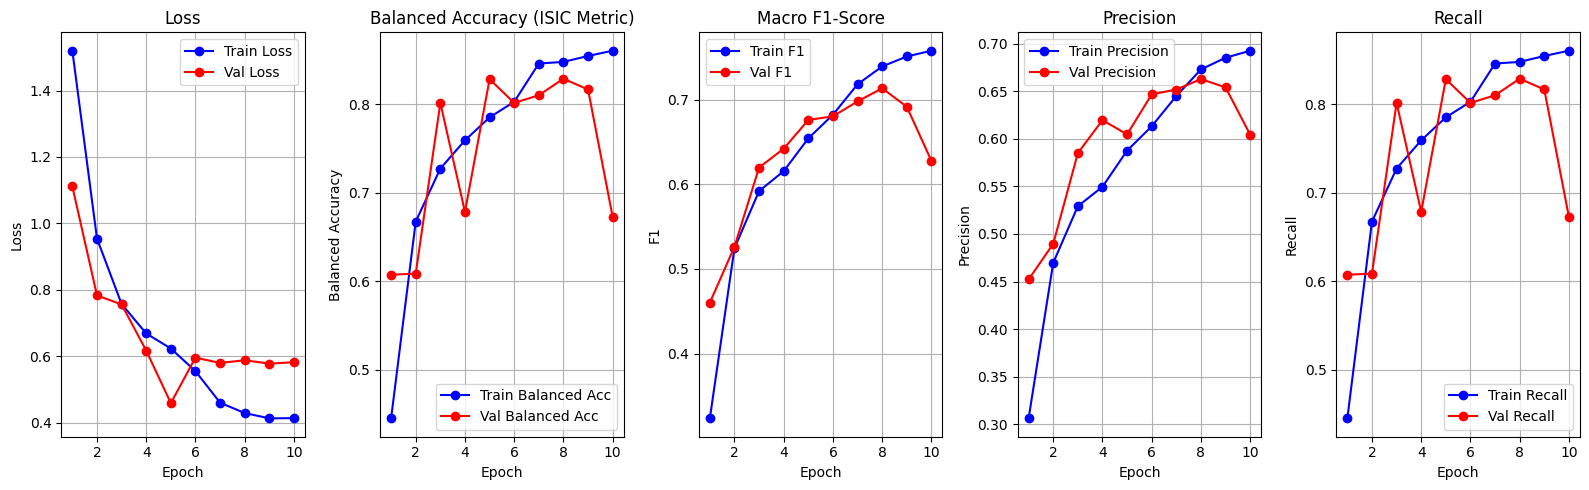

In [ ]:
# Plot evaluation metrics
plot_training_history(v2_model_ft_history)

Evaluating Confusion Matrix: 100%|██████████| 6/6 [00:02<00:00,  2.39it/s]


              precision    recall  f1-score   support

         MEL       0.64      0.67      0.65        21
          NV       0.99      0.84      0.91       123
         BCC       0.64      0.93      0.76        15
       AKIEC       0.36      0.50      0.42         8
         BKL       0.68      0.86      0.76        22
          DF       0.33      1.00      0.50         1
        VASC       1.00      1.00      1.00         3

    accuracy                           0.82       193
   macro avg       0.66      0.83      0.71       193
weighted avg       0.86      0.82      0.83       193

Normalized confusion matrix


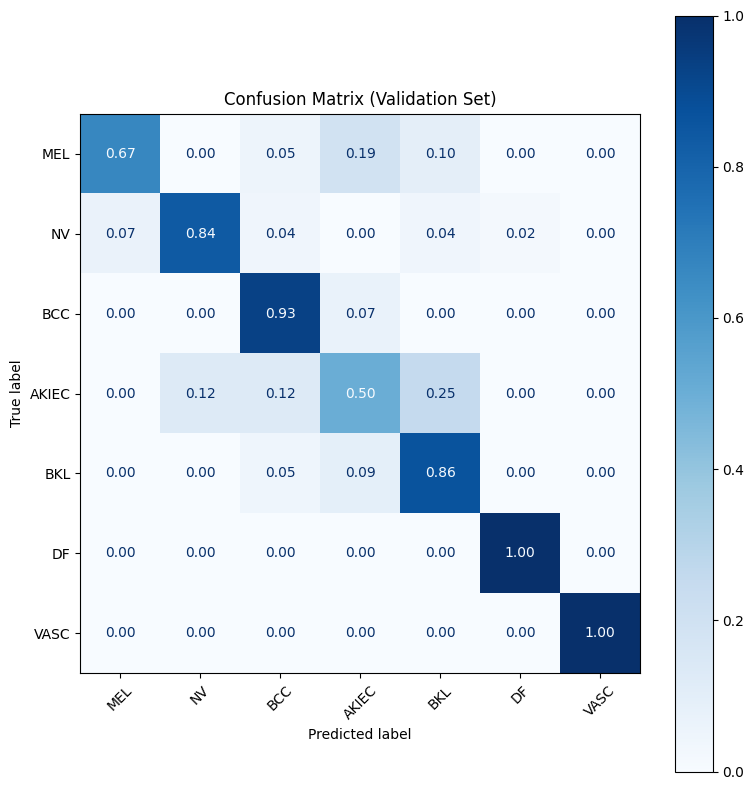

In [ ]:
# Confusion matri
cm_v2_ft = evaluate_confusion_matrix(v2_model_ft, val_loader, class_names, device, normalize = True)

Evaluating Confusion Matrix: 100%|██████████| 6/6 [00:02<00:00,  2.71it/s]


              precision    recall  f1-score   support

         MEL       0.64      0.67      0.65        21
          NV       0.99      0.84      0.91       123
         BCC       0.64      0.93      0.76        15
       AKIEC       0.36      0.50      0.42         8
         BKL       0.68      0.86      0.76        22
          DF       0.33      1.00      0.50         1
        VASC       1.00      1.00      1.00         3

    accuracy                           0.82       193
   macro avg       0.66      0.83      0.71       193
weighted avg       0.86      0.82      0.83       193

Confusion matrix, without normalization


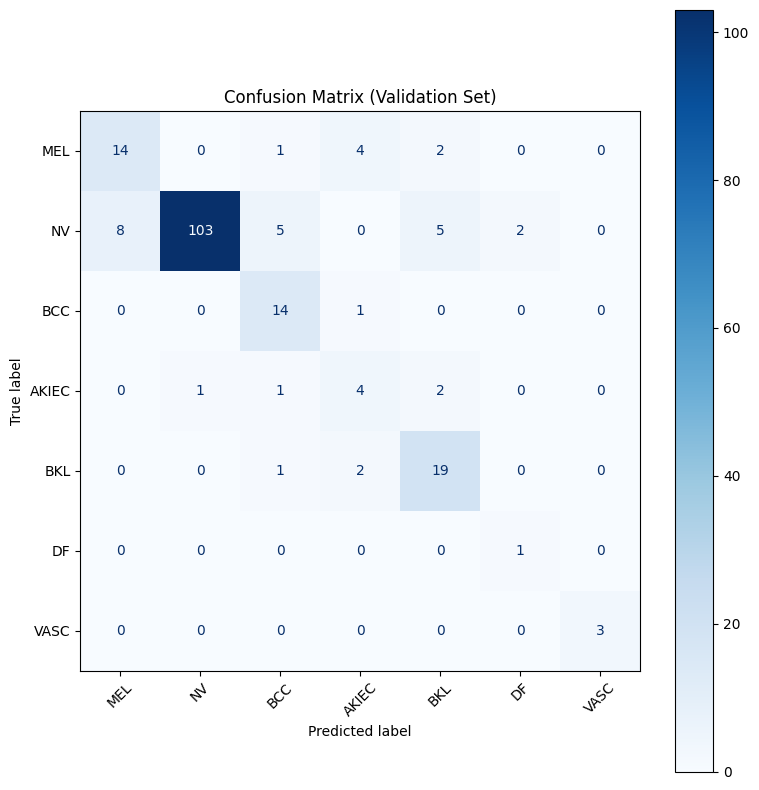

In [ ]:
cm_v2_ft = evaluate_confusion_matrix(v2_model_ft, val_loader, class_names, device, normalize = False)

### Train and evaluate v3 model (focal loss function) - see the other notebook

In [ ]:
# Training & Validation of v3 model with metrics tracking
# all layers unfreezed = finetuning

v3_model_ft, v3_model_ft_history = train_model(
    model=model, # resnet model with dropout for last fc layer
    dataloaders=dataloaders_v3_model,
    criterion=criterion_focal_loss,  # focal loss
    optimizer=optimizer_ft,
    scheduler=exp_lr_scheduler_ft,
    num_epochs=10,
    device=device
)

torch.save(v3_model_ft.state_dict(), "resnet50_skin_lesion_v3_model_ft_best_balacc.pth")
print("Model saved as resnet50_skin_lesion_v3_model_ft_best_balacc.pth")

In [ ]:
# Plots